<a href="https://colab.research.google.com/github/Yuri-Nassar/mat_tree/blob/master/TCC_multiAspectClustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Install libs

## Import libs

In [1]:
!pip install -U --q kaleido==0.2.1

In [2]:
%matplotlib inline
import os
import pandas as pd
import numpy as np
import math
from copy import deepcopy
from collections import namedtuple, defaultdict
import itertools
import json

from graphviz import Digraph
import networkx as nx
# import plotly.io as pio
from IPython.display import display#, display_html, HTML
import ipywidgets as widgets
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import kaleido

# from sklearn import metrics

import warnings
warnings.filterwarnings("ignore")

sns.set_theme()
sns.set(rc={'figure.figsize':(10.7,7.27)})

In [3]:
# dataset path
try:
  from google.colab import drive
  # !pip install plotly==5.10 -q
  # !pip install plotly==5.19 -q
  !pip install plotly==5.24.1 -q
  drive.mount('/content/drive')

  # project_path = "drive/MyDrive/Colab Notebooks/mat_tree"
  # dataset_path = "drive/MyDrive/Colab Notebooks/mat_tree/datasets"
  %cd drive/Othercomputers/"Meu laptop"/mat_tree
except:
  print("Running locally.")

import plotly.graph_objects as go

dataset_path = "datasets"

Running locally.


# Load dataset

In [4]:
dataset = 'basometro'
# dataset_version = 'basometro.csv'
dataset_version = 'basometro_v2.csv'

df = pd.read_csv(dataset_path+"/"+dataset+"/"+dataset_version, encoding='utf-8', parse_dates=['data'])
for col in ['partido', 'parlamentar', 'tipoProposicao']:
    df[col] = df[col].astype(str)
df.head()

,UF,voto,orientacaoGoverno,anoProposicao,anoVotacao,tipoProposicao,governo,parlamentar,data,idVotacao,...,alinhamento,esp_pol_partido,governo_alinhamento,partido_voto_sim_%,partido_voto_nao_%,partido_voto_abstencao_%,partido_voto_obstrucao_%,partido_voto_ausente_%,orientacao_partido_voto,alinhamento_candidato
0,PR,Sim,Sim,2002,2003,MSC,Lula_1,Abelardo Lupion,2003-02-25 18:54:00,25-2-2003.18.54.736,...,votou com o governo,Direita,Lula_1/votou com o governo,55.67,0.00,0.0,0.0,44.33,Sim,votou com o partido
1,PR,Sim,Sim,2002,2003,MPV,Lula_1,Abelardo Lupion,2003-03-18 19:30:00,18-3-2003.19.30.742,...,votou com o governo,Direita,Lula_1/votou com o governo,52.58,13.40,0.0,0.0,34.02,Sim,votou com o partido
2,PR,Sim,Não,1996,2003,PL,Lula_1,Abelardo Lupion,2003-03-19 18:37:00,19-3-2003.18.37.743,...,votou contra o governo,Direita,Lula_1/votou contra o governo,53.61,4.12,0.0,0.0,42.27,Sim,votou com o partido
3,PR,Sim,Não,2002,2003,MPV,Lula_1,Abelardo Lupion,2003-03-26 19:16:00,26-3-2003.19.16.746,...,votou contra o governo,Direita,Lula_1/votou contra o governo,59.79,5.15,0.0,0.0,35.05,Sim,votou com o partido
4,PR,Sim,Não,2003,2003,MPV,Lula_1,Abelardo Lupion,2003-04-08 18:02:00,8-4-2003.18.02.754,...,votou contra o governo,Direita,Lula_1/votou contra o governo,55.67,6.19,0.0,0.0,38.14,Sim,votou com o partido


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1019353 entries, 0 to 1019352
Data columns (total 29 columns):
 #   Column                    Non-Null Count    Dtype         
---  ------                    --------------    -----         
 0   UF                        1019353 non-null  object        
 1   voto                      1019353 non-null  object        
 2   orientacaoGoverno         1019353 non-null  object        
 3   anoProposicao             1019353 non-null  int64         
 4   anoVotacao                1019353 non-null  int64         
 5   tipoProposicao            1019353 non-null  object        
 6   governo                   1019353 non-null  object        
 7   parlamentar               1019353 non-null  object        
 8   data                      1019353 non-null  datetime64[ns]
 9   idVotacao                 1019353 non-null  object        
 10  tid                       1019353 non-null  int64         
 11  partido                   1019353 non-null  object

In [6]:
df = df.drop(columns=['horaVotacao','diaDaSemanaVotacao','diaDoAno','diaDoMesVotacao','mesVotacao','delayVotacaoAnos','partido_voto_sim_%','partido_voto_nao_%','partido_voto_abstencao_%','partido_voto_obstrucao_%','partido_voto_ausente_%','orientacao_partido_voto','alinhamento_candidato'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1019353 entries, 0 to 1019352
Data columns (total 16 columns):
 #   Column                  Non-Null Count    Dtype         
---  ------                  --------------    -----         
 0   UF                      1019353 non-null  object        
 1   voto                    1019353 non-null  object        
 2   orientacaoGoverno       1019353 non-null  object        
 3   anoProposicao           1019353 non-null  int64         
 4   anoVotacao              1019353 non-null  int64         
 5   tipoProposicao          1019353 non-null  object        
 6   governo                 1019353 non-null  object        
 7   parlamentar             1019353 non-null  object        
 8   data                    1019353 non-null  datetime64[ns]
 9   idVotacao               1019353 non-null  object        
 10  tid                     1019353 non-null  int64         
 11  partido                 1019353 non-null  object        
 12  diaDaSemanaVot

In [7]:
# Define a dictionary with column names and desired data types
# Example: {'partido': 'category', 'anoProposicao': 'int32', ...}
# Please fill in the dictionary with the columns and types you need.
column_types = {
    'voto': 'category',
    'orientacaoGoverno': 'category',
    'anoProposicao': 'int16',
    'tipoProposicao': 'category',
    'governo': 'category',
    'parlamentar': 'category',
    'tid': 'int16',
    'partido': 'category',
    'diaDaSemanaVotacaoNome': 'category',
    'alinhamento': 'category',
    'esp_pol_partido': 'category',
    'governo_alinhamento': 'category',
    'data' : 'datetime64[ns]'
    # Add other columns and their desired types here
}

# Convert columns based on the dictionary
for col, dtype in column_types.items():
    if col in df.columns:
        df[col] = df[col].astype(dtype)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1019353 entries, 0 to 1019352
Data columns (total 16 columns):
 #   Column                  Non-Null Count    Dtype         
---  ------                  --------------    -----         
 0   UF                      1019353 non-null  object        
 1   voto                    1019353 non-null  category      
 2   orientacaoGoverno       1019353 non-null  category      
 3   anoProposicao           1019353 non-null  int16         
 4   anoVotacao              1019353 non-null  int64         
 5   tipoProposicao          1019353 non-null  category      
 6   governo                 1019353 non-null  category      
 7   parlamentar             1019353 non-null  category      
 8   data                    1019353 non-null  datetime64[ns]
 9   idVotacao               1019353 non-null  object        
 10  tid                     1019353 non-null  int16         
 11  partido                 1019353 non-null  category      
 12  diaDaSemanaVot

In [8]:
df_bkp = df.copy()

In [9]:
# df = df_bkp.copy()

In [10]:
df['governo'].unique()

['Lula_1', 'Lula_2', 'Dilma_1', 'Temer_1', 'Dilma_2', 'Bolsonaro_1']
Categories (6, object): ['Bolsonaro_1', 'Dilma_1', 'Dilma_2', 'Lula_1', 'Lula_2', 'Temer_1']

- Filter by government

In [11]:
df_bkp = df.copy()
name_test_government = 'Bolsonaro_1' # all_governments, Lula_1, Lula_2, Dilma_1, Dilma_2, Temer_1, Lula_2, Bolsonaro_1

if name_test_government in df['governo'].unique():
  df = df[df['governo'] == name_test_government]
elif name_test_government == 'all_governments':
  df = df
else:
  print("Government not found!")

# Extra details digraph

## Color node digraph

In [12]:
def check_alignment(cluster_id, clusters):
  df_cluster = clusters[cluster_id]
  tot_votes = len(df_cluster)
  mask_not_inline = ((df_cluster['alinhamento'] == 'votou contra o governo') | (df_cluster['voto'] == 'Obstrução'))

  n_votes_not_inline = len(df_cluster[mask_not_inline])
  prop_not_inline = round(n_votes_not_inline/tot_votes, 4)

  if prop_not_inline >= 0.5:
    return False, prop_not_inline
  else:
    return True, round(1-prop_not_inline, 4)


# check_alignment('Lvl 3 - 2', TreeNode.df_leaves.copy())

In [13]:
# plot_sankey_flow(TreeNode.df_dict.copy(), df.copy(), ['governo', 'alinhamento', 'voto', 'esp_pol_partido', 'partido', 'tipoProposicao'], node_id, strat_split,
# plot_sankey_flow(TreeNode.df_dict.copy(), df.copy(), ['governo', 'alinhamento', 'voto', 'esp_pol_partido', 'partido', 'tipoProposicao'], node_id, strat_split,
def interpolate_color(value: float, support:bool):
  """Interpolate between two colors based on a value between 0 and 1."""

  adjusted_value = (value-0.5)*2 # bring the value close to 0.5 and then scale
  start_color = 'ffffff' # white
  start_color = [int(start_color[i:i+2], 16) for i in (0, 2, 4)]

  if support:
      end_color = '0E48A0'
      end_color = [int(end_color[i:i+2], 16) for i in (0, 2, 4)] # blue
  else:
      end_color = 'ff0000'
      end_color = [int(end_color[i:i+2], 16) for i in (0, 2, 4)] # red

  interpolated_color = [ int(start_color[i] + (end_color[i] - start_color[i]) * adjusted_value) for i in range(3) ]
  return '#{:02x}{:02x}{:02x}'.format(*interpolated_color)

In [14]:
def create_node(graph, node_name, color):
  """ Create a digraph node with color.
      Parameters:

  """

  graph.node(node_name, node_name, style='filled', fillcolor=color)

In [15]:
def create_color_node(cluster_id, graphTree, node_name):
  support, value = check_alignment(cluster_id, TreeNode.df_leaves)
  color = interpolate_color(value, support)
  # print(f"Cluster:{cluster_id}; Support: {support}; Value: {value}. Color: {color}")
  create_node(graphTree, node_name, color)

In [16]:
# df_gap = px.data.gapminder().query("year == 2007")
# df_gap.head()

In [17]:
# df_gap[df_gap['country'] == 'Brazil']

## Include majority info node

In [18]:
def get_major_info_cluster(cluster_id:str, df_clusters:dict):
  """ Method to get the party and proposition that are majority in a cluster
      regarding the support type.
  """

  df_cluster = df_clusters[cluster_id].copy()
  major_party = ""
  major_proposition = ""

  support, prop_value = check_alignment(cluster_id, df_clusters)
  mask_not_inline = ((df_cluster['alinhamento'] == 'votou contra o governo') | (df_cluster['voto'] == 'Obstrução'))

  if support:
    df_inline = df_cluster[~mask_not_inline]
    major_party = df_inline['partido'].value_counts().idxmax()
    major_proposition = df_inline['tipoProposicao'].value_counts().idxmax()
  else:
    df_not_inline = df_cluster[mask_not_inline]
    major_party = df_not_inline['partido'].value_counts().idxmax()
    major_proposition = df_not_inline['tipoProposicao'].value_counts().idxmax()

  return f"[{major_party} & {major_proposition}]\n{'Support' if support else 'Opposite'}={str(round(prop_value*100,2))}%"

In [19]:
#get_major_info_cluster(cluster_id='Lvl 3 - 2', df_clusters=TreeNode.df_leaves.copy())

# Algorithm

### Sankey

In [20]:
def sankey(cls, label, value):
  """
    Creates a sankey diagram from class dataset. Sankey diagram is a type of
    flow diagram in which the width of the arrows is proportional to the
    flow rate.
  """
  # print(f'label: {label}')
  # print(f'value: {value}')
  # print(f'source: {cls.source}')
  # print(f'id_dict: {cls.id_dict}')
  # print(f'nodeLabel: {cls.nodeLabel}')


  ### give an unique id for labels since it can repeat
  label_to_id = {}
  id = 0
  for k, v in label.items():
    for i in range(len(v)):
      label_to_id[v[i]] = id
      id+=1
  # print(f'label_to_id: {label_to_id}')

  ## source-target-count
  source = []
  target = []
  count = []
  for k, v in label.items():
    id_next_node = 0
    for label_name in v:
      counter = 0
      for i in cls.nodeLabel[k+1]:
        if (counter <= 1) & (label_name.split('#')[0] != 'c'):
          source.append(label_name)
          target.append(label[k+1][id_next_node])
          count.append(value[k][id_next_node])
          id_next_node+=1
          counter+=1
        else:
          break

  data_link = {'source':source,
              'target':target,
              'count':count}
  # print(f'data_link: {data_link}')

  df_source_target = pd.DataFrame(data_link, columns=['source','target','count'])
  # display(df_source_target)
  df_source_target = df_source_target.replace({'source':label_to_id, 'target':label_to_id})
  # display(df_source_target)


  label = list(itertools.chain.from_iterable(label.values()))
  value = list(itertools.chain.from_iterable(value.values()))
  source = [val for val in cls.source for _ in (0, 1)]
  target = [tar for tar in range(1, len(source) + 1)]

  # link = dict(source=source, target=target, value=value)
  # node = dict(label=label, pad=20, thickness=5)
  link = dict(source=df_source_target['source'].values, target=df_source_target['target'],
              value=df_source_target['count'])

  def get_labels(raw_labels):
    labels = []
    for i in range(len(raw_labels)):
      tmp = raw_labels[i]
      try:
        labels.append(tmp.split('/')[0]+"<br>"+tmp.split('/')[1])
      except:
        labels.append(tmp)
    return labels

  # node = dict(label=list(label_to_id.keys()), pad=15, thickness=5)
  node = dict(label=get_labels(list(label_to_id.keys())), pad=15, thickness=5)

  data = go.Sankey(link=link, node=node
                   ,arrangement='snap'
                  #  ,orientation='h'
                   ,valueformat = ".0f",)
  plt.figure(figsize=(10, 6))
  fig = go.FigureWidget(data=data)
  # fig.update_layout(title_text="Basic Sankey Diagram", font_size=10,plot_bgcolor='black',
  #                   paper_bgcolor='black',
  #                   width=500, height=500)
  fig.update_layout(width=1000, height=650)
  fig.show()

### EDA

In [21]:
def eda(cls, dataset, feature, usr=None):
  """
  Exploratory Data Analysis. It generates a plot bar of a given feature of
  a given dataset and a given user.

  Parameters
  ----------
  dataset : pandas.DataFrame
    Dataset of trajectories of a given cluster.
  feature : str
    Feature or Aspect intended for EDA.
  user : int
    User label in a given cluster.
  """
  idx = dataset.index

  df_total = df.copy()
  df1 = df[df.tid.isin(idx)]

  if usr is not None and usr is not 'ALL':
    df_total = df_total[df_total.label == usr]
    df1 = df1[df1.label == usr]


  df_total.reset_index(inplace=True)
  df1.reset_index(inplace=True)

  place_type_abs = df_total[feature]
  place_type = df1[feature]


  ''' Frequency per cluster '''
  values = np.sort(np.unique(place_type_abs))
  freq = np.zeros(len(values))
  ind = 0
  for i in values:
      counter = 0
      for j in range(0,len(place_type)):
          if(place_type[j] == i):
            counter = counter + 1
      freq[ind] = counter
      ind = ind + 1

  ''' Absolute frequency '''
  values_abs = np.sort(np.unique(place_type_abs))
  freq_abs = np.zeros(len(values_abs))
  ind_abs = 0
  for k in values_abs:
      counter = 0
      for l in range(0,len(place_type_abs)):
          if(place_type_abs[l] == k):
            counter = counter + 1
      freq_abs[ind_abs] = counter
      ind_abs = ind_abs + 1

  relative = []
  for i in range(len(freq)):
    relative.append(f'{(freq[i]/freq_abs[i])*100}')

  fig= plt.figure(figsize=(15,5))
  ax = plt.gca()


  y_pos = np.arange(len(values))
  plt.xticks(y_pos, values)
  plt.bar(y_pos, freq)
  plt.xticks(fontsize=10, rotation='vertical')
  plt.yticks(fontsize=10)
  plt.xlabel("Aspect values",fontsize = 15)
  plt.ylabel("Frequency", fontsize = 15)
  plt.title(f"Relative frequency for aspect '{feature}'")

  for i, p in enumerate(ax.patches):
      ax.text(p.get_x() + p.get_width()/2., p.get_height(), f'{int(p.get_height())} ({relative[i]:.4}%)',
              fontsize=10, color='black', ha='center', va='bottom')

### EDA CORR

In [22]:
def eda_corr(cls, dataset, usr):
  """
  Exploratory Data Analysis. It generates a plot of correlation matrix of
  all features of a given dataset and a given user.

  Parameters
  ----------
  dataset : pandas.DataFrame
    Dataset of trajectories of a given cluster.
  user : int
    User label in a given cluster.
  """
  idx = dataset.index
  ds = df[df.tid.isin(idx)]

  if usr is not None:
    ds = ds[ds.label == usr]

  if dataset_version.split('_')[0] == 'fsny':
    # columns = ['tid', 'time', 'poi', 'type', 'rating', 'label', 'weather']
    columns = TreeNode.useCol
  else:
    cols1   = df.columns.tolist()
    # cols2   = ['partido', 'alinhamento', 'orientacaoGoverno', 'voto'
    #            , 'tipoProposicao'#, 'anoVotacao'#, 'anoProposicao'
    #            , 'governo']
    cols2 = TreeNode.useCol
    columns = list(set(cols1).difference(set(cols2)))

  ds = ds.drop(columns=columns)
  corr = pd.get_dummies(ds)
  corr = corr.corr()

  plt.figure(figsize=(10, 4))
  plt.imshow(corr, cmap='Blues', interpolation='none', aspect='auto')
  plt.colorbar()
  plt.xticks(range(len(corr)), corr.columns, rotation='vertical')
  plt.yticks(range(len(corr)), corr.columns);
  plt.suptitle('Correlation between variables', fontsize=15, fontweight='bold')
  plt.grid(False)

### Entropy

In [23]:
def get_entropy(dataset):
  """
    Calculates the entropy value of a given dataset.

    Parameters
    ----------
    dataset : pandas.DataFrame
      Dataset of trajectories of a given cluster

    Returns
    -------
    Float
      Entropy value of a given cluster.
  """
  df1 = dataset.copy()
  entropy_dict = {}
  for e in df1['partido'].unique():
    num_traj = df1[df1['partido'] == e]['tid'].unique()
    entropy_dict[e] = len(num_traj)
  total = sum(entropy_dict.values())

  entropy_value = 0
  for key, value in entropy_dict.items():
    p = value/total
    entropy_value += p * math.log2(p)

  try:
    max_entropy = math.log2(len(df1['partido'].unique()))
    return -entropy_value/max_entropy
  except:
    return -entropy_value
  # return -entropy_value/max_entropy

### Similarity Matrix

In [24]:
def get_similarity_matrix(dataset, sim_measure):
    """
      Creates the distance matrix of the trajectories of a given cluster using
      the given similarity metric.

      Parameters
      ----------
      dataset : pandas.DataFrame
        Dataset of trajectories of a given cluster
      sim_measure : str
        Similarity metric [MUITAS, MSM, EDR, LCSS].

      Returns
      -------
      pandas.DataFrame
        A dataframe of [MUITAS, MSM, EDR, LCSS] similarity metric.
    """

    df_tid = dataset.tid.unique()
    cols = []
    # Select columns according to trajectories
    for e in df_tid:
        # if int(e) <= 29563:# usando dataset do FS. Basomentro é maior entao precisa limitar
        cols.append(str(e))

    df_aux = None
    sim_matrix = None
    if sim_measure == 'MUITAS':
        sm_file = dataset_path+"/"+dataset_version.split('_')[0]+"/muitas.csv"
        tmp = pd.read_csv(sm_file)
        cols2 = tmp.columns
        cols_intersec = list(set(cols).intersection(set(cols2)))
        sim_matrix = pd.read_csv(sm_file, usecols=cols_intersec)

    elif sim_measure == 'MSM':
        sm_file = dataset_path+"/"+dataset_version.split('_')[0]+"/msm.csv"
        tmp = pd.read_csv(sm_file)
        cols2 = tmp.columns
        cols_intersec = list(set(cols).intersection(set(cols2)))
        sim_matrix = pd.read_csv(sm_file, usecols=cols_intersec)

    elif sim_measure == 'EDR':
        sm_file = dataset_path+"/"+dataset_version.split('_')[0]+"/edr.csv"
        tmp = pd.read_csv(sm_file)
        cols2 = tmp.columns
        cols_intersec = list(set(cols).intersection(set(cols2)))
        sim_matrix = pd.read_csv(sm_file, usecols=cols_intersec)

    elif sim_measure == 'LCSS':
        sm_file = dataset_path+"/"+dataset_version.split('_')[0]+"/lcss.csv"
        tmp = pd.read_csv(sm_file)
        cols2 = tmp.columns
        cols_intersec = list(set(cols).intersection(set(cols2)))
        sim_matrix = pd.read_csv(sm_file, usecols=cols_intersec)

    df_aux = sim_matrix.copy()
    idx = []

    # Select rows according to trajectories
    for c in sim_matrix:
        idx.append(df_aux.columns.get_loc(c))
    sim_matrix = sim_matrix[sim_matrix.index.isin(idx)]

    del df_aux, df_tid, idx, cols, cols2, cols_intersec, tmp

    return sim_matrix.set_index(sim_matrix.columns)

### TreeNode

In [25]:
def build_class():

  class TreeNode:
      """
        A class used to represent a node in a Tree.

        Attributes
        ----------
        TODO

        Methods
        -------
        set_level: Defines the cluster label.
        check_label: Method used to verify cluster aspect label in order to avoid
                    duplicate names in Sankey Diagram.
        sankey: Creates a sankey diagram from class dataset. Sankey diagram is a
                type of flow diagram in which the width of the arrows is
                proportional to the flow rate.
        eda: Exploratory Data Analysis. It generates a plot bar of a given feature of
              a given dataset and a given user.
        eda_corr: Exploratory Data Analysis. It generates a plot of correlation
                  matrix of all features of a given dataset and a given user.
        get_similarity_matrix: Creates the distance matrix of the trajectories of
                              a given cluster using the given similarity metric.
        get_entropy: Calculates the entropy value of a given dataset.
        dashboard: Displays the result dashboard.
        show: Shows info about each cluster node.
        graphicTree: Shows info about each cluster node in the tree generated by Digraph
                    plot.
        dashTree: Method that calculates the frequency matrix and the clusters
                  generated from the division of data based on a split criteria
                  defined in the Tree constructor.

      """

      # Select option in dashboard
      SELECT = 'Select Node'
      ALL = 'ALL'
      HEATMAP = 'HEATMAP'

      # dict to store the threshold of each selected aspect to split the set of trajectories
      threshold_nodes = {}

      # Sankey diagram params
      label = defaultdict(list)
      value = defaultdict(list)
      source = []

      id_dict = defaultdict(list)
      id_list = []

      # Params to label tree nodes
      nodeNum, targetNum = -1, -1
      nodeLabel = defaultdict(list)

      # 1. Dictionary of all nodes dataframes
      # 2. Dictionary of all leaves nodes dataframes
      df_dict = {}
      df_leaves = {}

      ############################################################################
      # Frequency matrix for the initial dataset
      absolute_frequency_matrix = None
      relative = True

      ############################################################################
      temporario = 0
      clusters = 0
      dendrogram_dict = defaultdict(list)

      ############################################################################
      var_dict = {}
      id_iter = itertools.count()

      temp = {}

      ## Aspects to use in the analysis
      # useCol = ['partido', 'alinhamento', 'orientacaoGoverno', 'voto', 'tipoProposicao', 'governo']# independents
      useCol = ['partido', 'governo_alinhamento', 'orientacaoGoverno', 'tipoProposicao',]# combined
      # useCol = ['partido', 'alinhamento', 'orientacaoGoverno', 'tipoProposicao',]# simple

      def __init__(self, df, par=None):
          """DOC - __init__"""

          self.parent = par
          self.parentName = ''
          self.data = df
          self.left = None
          self.leftChildName = ''
          self.right = None
          self.rightChildName = ''
          self.done = 'No'
          self.freqMatrix = None
          self.variance = None
          self.threshold = None
          self.left_group = {}
          self.right_group = {}

          self.division = ''
          self.thresholdVal = None
          self.maxTrajPerGroup = 50
          self.maxDepth = 2

          if par == None:
              # binary, minVariance, var_red, max_red
              self.split = 'max_red'
          else:
              self.split = par.split

          self.trajList = self.data.tid.unique()
          # self.useCol = ['day', 'weather', 'root_type'] # fsny
          self.useCol = TreeNode.useCol

          if self.parent is not None:
              self.skipVal = deepcopy(self.parent.skipVal)
          else:
              self.skipVal = []

          if self.parent is None:
              self.depth = 0
          else:
              self.depth = par.depth + 1

          if par is None:
              self.id = f'Lvl {self.depth}'
          else:
              self.id = self.set_level(self.depth)

      def set_level(self, depth):
          """
          Defines the cluster label.

          Parameters
          ----------
          depth : int
            Tree depth level.
          """
          id = 0
          while True:
              if id not in self.id_dict[depth]:
                  self.id_dict[depth].append(id)
                  return f'Lvl {depth} - {id}'
              if id in self.id_dict[depth]:
                  id += 1

      def check_label(self, label, depth):
          """
          Method used to verify cluster aspect label in order to avoid duplicate
          names in Sankey Diagram.

          Parameters
          ----------
          label : str
            Cluster aspect label.
          depth : int
            Cluster depth level.
          """

          items = list(itertools.chain.from_iterable(dict(TreeNode.label).values()))

          if label in items:
              if '#' in label:
                  label, num = label.split('#')
                  label = label+"#"+str(int(num)+1)
                  self.check_label(label, depth)
              else:
                  label += f'#1'
                  self.check_label(label, depth)
          else:
              TreeNode.label[depth].append(label)



      def generate_freq_matrix(self):

          cat_cols = self.useCol
          columns_to_drop = list(set(list(df.columns)).difference(set(list(self.useCol))))
          columns_to_drop.remove("tid")
          columns = self.data.drop(columns_to_drop, axis=1)

          for col in cat_cols:
            if col in list(columns.columns):
              columns[col] = columns[col].astype('category')

          dummies = pd.get_dummies(columns, prefix_sep='~')
          vals = dummies.drop(['tid'], axis=1)
          self.freqMatrix = pd.pivot_table(dummies, index=['tid'], values=vals.columns, aggfunc=np.sum).astype('int16')
          del columns, dummies, vals

      @classmethod
      def dashboard(cls, array, strat_split, min_trajs, max_depth):
          """
            Displays the result dashboard.

            output: displays the frequency matrix of a given cluster
            output_3: displays the graphic tree
            output_4: displays the Sankey Diagram
            output_5: displays the cluster pandas.Dataset and info about the cluster
            output_6: displays EDA plots of a given cluster
            output_8: displays the similarity matrix of a given cluster
            plot_output: displays the heat map plots of a given cluster

            Parameters
            ----------
            array : dict
              Dictionary of resulting nodes.

          """
          root = cls(df)
          root.dashTree(strat_split, min_trajs, max_depth)

          def getDictKeys(array_dict):
              keys = list(array_dict.keys())
              keys.sort()
              keys.insert(0, cls.SELECT)
              keys.insert(1, cls.ALL)
              return keys

          def getUsers(data_frame):
              user = data_frame['partido'].unique().tolist()
              user.insert(0, cls.ALL)
              return user

          dropdown_df = widgets.Dropdown(options=getDictKeys(TreeNode.df_dict), description='Tree Node')
          row_num = widgets.IntText(value=5, step=1, description='# rows')
          dropdown_label = widgets.Dropdown(options=getUsers(df), description='Select User')
          item_layout = widgets.Layout(margin='0 0 10px 0')

          input_widgets = widgets.HBox([dropdown_df, row_num, dropdown_label], layout=item_layout)

          output = widgets.Output()
          # output_2 = widgets.Output()
          output_3 = widgets.Output()
          output_4 = widgets.Output()
          output_5 = widgets.Output()
          output_6 = widgets.Output()
          # output_7 = widgets.Output()
          output_8 = widgets.Output()
          plot_output = widgets.Output()

          tab = widgets.Tab([output_3, output_5, output_8, output_6, output, output_4, plot_output], layout=item_layout)

          def update_dashboard(dataset, num, user):

              output.clear_output()
              # output_2.clear_output()
              output_3.clear_output()
              output_4.clear_output()
              output_5.clear_output()
              output_6.clear_output()
              # output_7.clear_output()
              output_8.clear_output()
              plot_output.clear_output()

              with output:
                  if (dataset == cls.ALL) or (dataset == cls.SELECT):
                      display(df.head(num))
                  else:
                      display(TreeNode.df_dict[dataset].head(num))

              # graph
              with output_3:
                  graph = Digraph(node_attr={'fixedsize':'true', 'width':'1.5',
                                            'height':'.8', 'fontsize':'8','fontname':'bold'})
                  # graph.attr(size="40")
                  graph.attr()
                  root.graphicTree(graph)

                  graph.render('output_tree_vectorized', format='pdf', cleanup=True)
                  display(graph)

              with output_4:
                  sankey(cls, TreeNode.label, TreeNode.value)
                  # plt.show()

              with output_5:
                  if (dataset == cls.ALL) or (dataset == cls.SELECT):
                      display(df.head(num))
                  else:
                      idx = TreeNode.df_dict[dataset].index
                      df_filter = df[df.tid.isin(idx)]
                      print(f'Node: {dataset}')
                      print(f'The users in this node are: {df_filter["partido"].unique()}')
                      print(f'# users: {len(df_filter["partido"].unique())}')
                      print(f'There are {len(df_filter.tid.unique())} trajectories in this node.\n')

                      print(f'Entropy (Trajectories/User): {get_entropy(df_filter)}\n')

                      if user == 'ALL':
                          display(df_filter.head(num))

                      if user in df_filter['partido'].unique():
                          dt = df_filter[df_filter['partido'] == user]
                          total = len(df[df['partido']==user].tid.unique())
                          local = len(dt.tid.unique())
                          print(
                              f"""Showing results for user {user}. User {user} has {local} trajectories in this node of  {total} ({np.round((local/total)*100,2)}%)."""
                              )
                          print(f'Trajectory(ies) are: {[x for x in dt.tid.unique()]}')
                          display(dt.head(num))
                      else:
                          if user != 'ALL':
                              print('This user is not present in this node.')

              with output_6:
                  # if user == 'ALL':
                  #   dataset = 'Lvl 0'

                  # first_asp  = 'root_type' if dataset_version.split('_')[0] == 'fsny' else 'label'
                  # second_asp = 'day' if dataset_version.split('_')[0] == 'fsny' else 'alinhamento'

                  if user == 'ALL':
                      eda(cls, TreeNode.df_dict['Lvl 0'], 'partido', usr=None)
                  else:
                      eda(cls, TreeNode.df_dict[dataset], 'partido', usr=user)

                  if user == 'ALL':
                      eda(cls, TreeNode.df_dict['Lvl 0'], 'alinhamento', usr=None)
                  else:
                      eda(cls, TreeNode.df_dict[dataset], 'alinhamento', usr=user)

                  if user == 'ALL':
                      eda_corr(cls, TreeNode.df_dict['Lvl 0'], usr=None)
                  else:
                      eda_corr(cls, TreeNode.df_dict[dataset], usr=user)
                  plt.show()

              # with output_7:
              #     display(TreeNode.var_dict[dataset])

              with output_8:
                  if (dataset == cls.ALL) or (dataset == cls.SELECT):
                      print("Select node.")
                  else:
                      idx = TreeNode.df_dict[dataset].index
                      df_filter = df[df.tid.isin(idx)]
                      print(f"Users in this node:{df_filter['partido'].unique()}")

                      ## if user != 'ALL':
                      ##   df_user = df_filter[df_filter.label == user]
                      ##   muitas_sm = get_similarity_matrix(df_user, 'MUITAS')
                      ## else:
                      ##   muitas_sm = get_similarity_matrix(df_filter, 'MUITAS')
                      muitas_sm = get_similarity_matrix(df_filter, 'MUITAS')

                      ## trajs_id = df_filter.tid.astype(str).unique().tolist()

                      similarity_mean_node_muitas = get_similarity_matrix(df_filter, 'MUITAS')
                      similarity_mean_node_muitas = sum(similarity_mean_node_muitas.mean()) / len(
                          similarity_mean_node_muitas)

                      similarity_mean_node_msm = get_similarity_matrix(df_filter, 'MSM')
                      similarity_mean_node_msm = sum(similarity_mean_node_msm.mean()) / len(similarity_mean_node_msm)

                      print(f'MUITAS')
                      print(
                          f'The average of similarity between the trajectories of this cluster/node is: {similarity_mean_node_muitas}')
                      print(f'MSM')
                      print(
                          f'The average of similarity between the trajectories of this cluster/node is: {similarity_mean_node_msm}')

                      muitas_user_avg = sum(muitas_sm.mean())/len(muitas_sm)
                      print(f'\nSimilarity Matrix (user:{user}; MUITAS: {muitas_user_avg}):')

                      # display(get_similarity_matrix(df_filter, 'MUITAS').head(num))
                      display(muitas_sm.head(num))

              ### heatmap ###
              with plot_output:
                  plt.figure(figsize=(10,4))
                  if dataset == cls.ALL:
                      ax = sns.heatmap(df)
                      ax.set_yticklabels(df.tid, size = 12)
                  else:
                      ax = sns.heatmap(TreeNode.df_dict[dataset])
                      # ax.set_yticklabels(TreeNode.df_dict[dataset]['tid'], size = 12)
                  ax.set_yticklabels(ax.get_yticklabels(), size = 8)
                  plt.show()

          def dropdown_eventhandler(change):
              update_dashboard(change.new, row_num.value, dropdown_label.value)

          def row_num_eventhandler(change):
              update_dashboard(dropdown_df.value, change.new, dropdown_label.value)

          def dropdown_label_eventhandler(change):
              update_dashboard(dropdown_df.value, row_num.value, change.new)

          dropdown_df.observe(dropdown_eventhandler, names='value')
          row_num.observe(row_num_eventhandler, names='value')
          dropdown_label.observe(dropdown_label_eventhandler, names='value')

          tab.set_title(0, 'Tree View')
          tab.set_title(1, 'Trajectory View')
          tab.set_title(2, 'Trajectory Similarity')
          tab.set_title(3, 'EDA')
          tab.set_title(4, 'Dataset Exploration')
          tab.set_title(5, 'Sankey View')
          tab.set_title(6, 'Heatmap Plot')

          display_dashboard = widgets.VBox([input_widgets, tab])
          display(display_dashboard)


      def show(self, onlyLeaf=False):
          """
            Shows info about each cluster node.

            Parameters
            ----------
            onlyLeaf : bool
              A boolean attribute to determine if all nodes should be displayed
              or only leaf nodes.
          """

          if not onlyLeaf or len(self.division) <= 0:
              print('==' * self.depth, 'Node id: ', self.id)
              if self.parent is None:
                  print('==' * self.depth, 'Parent id: None')
              else:
                  print('==' * self.depth, 'Parent id: ', self.parent.id)
                  print('==' * self.depth, 'Node depth: ', self.depth)
                  print('==' * self.depth, 'Dataset shape (points x aspects): ', self.data.shape)
                  print('==' * self.depth, 'Number of trajectories: ', self.trajList.size)
                  print('==' * self.depth, '# of Users on this node =', self.data['partido'].unique().size)
                  print('==' * self.depth, 'Users on this node =', self.data['partido'].unique())
              if len(self.division) > 0:
                  print('==' * self.depth, 'Division done using the aspect', self.division['aspect'], ' with value ',
                        self.division['value'], '; Frequency threshold = ', self.threshold)
                  print('==' * self.depth, 'Trajectories on the left node = ', self.left.trajList.size)
                  print('==' * self.depth, 'Trajectories on the right node = ', self.right.trajList.size)
              else:
                  print('==' * self.depth, 'Leaf node')
              print(' ')

          if self.left is not None:
              self.left.show(onlyLeaf)
          if self.right is not None:
              self.right.show(onlyLeaf)

      def graphicTree(self, graphTree):
          """
            Shows info about each cluster node in the tree generated by Digraph
            plot.

            Parameters
            ----------
            graphTree : Digraph
              A base class for directed graphs.
          """

          threshold = '{:.4f}'.format(self.thresholdVal)
          if self.left.thresholdVal is not None and self.right.thresholdVal is not None:
              thresholdLeft = '{:.4f}'.format(self.left.thresholdVal)
              thresholdRight = '{:.4f}'.format(self.right.thresholdVal)
          elif self.left.thresholdVal is not None and self.right.thresholdVal is None:
              thresholdLeft = '{:.4f}'.format(self.left.thresholdVal)
          elif self.left.thresholdVal is None and self.right.thresholdVal is not None:
              thresholdRight = '{:.4f}'.format(self.right.thresholdVal)

          tres_ = "\nMean_tres["
          if self.split == 'binary':
              left = 'NO'
              right = 'YES'
              thres = ''
          else:
              left = 'less than the average'
              right = 'greater than the average'
              thres = tres_ + str(threshold) + "]"

          n_tids_parent  = "\nnum_TIDs("+str(int(self.freqMatrix.index.nunique()))+")"
          n_tids_left    = "\nnum_TIDs("+str(int(self.left.freqMatrix.index.nunique()))+")"
          n_tids_right   = "\nnum_TIDs("+str(int(self.right.freqMatrix.index.nunique()))+")"

          if self.left.done == 'No' and self.right.done == 'No':
              graphTree.edge(str(self.id) + "\n" + self.parentName + n_tids_parent + tres_ + str(threshold) + "]",
                            str(self.left.id) + "\n" + self.leftChildName + n_tids_left + tres_ + str(thresholdLeft) + "]", left)
              graphTree.edge(str(self.id) + "\n" + self.parentName + n_tids_parent + tres_ + str(threshold) + "]",
                            str(self.right.id) + "\n" + self.rightChildName + n_tids_right + tres_ + str(thresholdRight) + "]", right)

          elif self.left.done == 'No' and self.right.done == 'Yes':
              graphTree.edge(str(self.id) + "\n" + self.parentName + n_tids_parent + tres_ + str(threshold) + "]",
                            str(self.left.id) + "\n" + self.leftChildName + n_tids_left +  tres_ + str(thresholdLeft) + "]", left)
              node_name = str(self.right.id) + "\n" + "num_TIDs("+self.rightChildName+")"
              mic = get_major_info_cluster(self.right.id, TreeNode.df_leaves.copy())
              node_name += f"\n{mic}"
              create_color_node(self.right.id, graphTree, node_name)
              graphTree.edge(str(self.id) + "\n" + self.parentName + n_tids_parent + tres_ + str(threshold) + "]",
                            node_name, right)

          elif self.left.done == 'Yes' and self.right.done == 'No':
              node_name = str(self.left.id) + "\n" + "num_TIDs("+self.leftChildName+")"
              mic = get_major_info_cluster(self.left.id, TreeNode.df_leaves.copy())
              node_name += f"\n{mic}"
              create_color_node(self.left.id, graphTree, node_name)
              graphTree.edge(str(self.id) + "\n" + self.parentName + n_tids_parent + tres_ + str(threshold) + "]",
                            node_name, left)
              graphTree.edge(str(self.id) + "\n" + self.parentName + n_tids_parent + tres_ + str(threshold) + "]",
                            str(self.right.id) + "\n" + self.rightChildName + n_tids_right + tres_ + str(thresholdRight) + "]", right)

          else:
              node_name = str(self.left.id) + "\n" + "num_TIDs("+self.leftChildName+")"
              mic = get_major_info_cluster(self.left.id, TreeNode.df_leaves.copy())
              node_name += f"\n{mic}"
              create_color_node(self.left.id, graphTree, node_name)
              graphTree.edge(str(self.id) + "\n" + self.parentName + n_tids_parent + tres_ + str(threshold) + "]",
                            node_name, left)

              node_name = str(self.right.id) + "\n" + "num_TIDs("+self.rightChildName+")"
              mic = get_major_info_cluster(self.right.id, TreeNode.df_leaves.copy())
              node_name += f"\n{mic}"
              create_color_node(self.right.id, graphTree, node_name)
              graphTree.edge(str(self.id) + "\n" + self.parentName + n_tids_parent + tres_ + str(threshold) + "]",
                            node_name, right)

          if self.left.done == 'No':
              self.left.graphicTree(graphTree)
          if self.right.done == 'No':
              self.right.graphicTree(graphTree)

      def dashTree(self, strat_split, min_trajs, max_depth):
          """
            Method that calculates the frequency matrix and the clusters generated
            from the division of data based on a split criteria defined in the
            Tree constructor.

          """

          """
            columnns: gets only the relevant aspects (attributes)
            dummies: converts categorical variable into dummy/indicator variables.
            vals: removes the 'tid' column
            freqMatrix: creates a spreadsheet-style pivot table as a DataFrame
                        from dummies and vals.
          """
          # columns = self.data.drop(['time', 'poi', 'type', 'rating', 'label'], axis=1)
          # dummies = pd.get_dummies(columns, prefix_sep='~')
          # vals = dummies.drop(['tid'], axis=1)
          # self.freqMatrix = pd.pivot_table(dummies, index=['tid'], values=vals.columns, aggfunc=np.sum)
          self.generate_freq_matrix()
          self.split = strat_split
          self.maxTrajPerGroup = min_trajs
          self.maxDepth = max_depth

          if TreeNode.relative and TreeNode.absolute_frequency_matrix is None:
              TreeNode.absolute_frequency_matrix = self.freqMatrix.sum()
              dt = [res for res in self.freqMatrix.mean()]
              TreeNode.absolute_frequency_matrix = pd.DataFrame(columns=['mean'], data=dt, index=self.freqMatrix.columns)

          ### Stop criterion ###
          if (self.trajList.size <= 1 or
            (self.maxTrajPerGroup > 0 and self.trajList.size < self.maxTrajPerGroup) or
                  (self.depth == self.maxDepth)
                  ):

              self.parentName = str(self.data.tid.unique().size)
              self.done = 'Yes'
              self.check_label('c', self.depth)
              TreeNode.df_dict[str(self.id)] = self.freqMatrix
              TreeNode.nodeLabel[self.depth].append(self.id)

              idx = TreeNode.df_dict[str(self.id)].index
              df_filter = df[df.tid.isin(idx)]
              TreeNode.df_leaves[str(self.id)] = df_filter

              TreeNode.temporario += get_entropy(df_filter) * len(df_filter.tid.unique())
              TreeNode.clusters += 1

              TreeNode.dendrogram_dict[str(self.id)] = []

              return 0

          TreeNode.nodeNum += 1
          TreeNode.source.append(TreeNode.nodeNum)

          minVar = -1

          if TreeNode.relative:
              dt = [res for res in self.freqMatrix.sum() / len(df)]
              self.threshold = pd.DataFrame(columns=['mean'], data=dt, index=self.freqMatrix.columns)
          else:
              dt = [res for res in self.freqMatrix.mean()]
              self.threshold = pd.DataFrame(columns=['mean'], data=dt, index=self.freqMatrix.columns)

          self.variance = {}
          left_dict = {}
          right_dict = {}
          feature_list, initial_var, var_red = [], [], []
          reducao = {}
          split_value = {}
          muitas_result = {}
          msm_result = {}

          for col in self.freqMatrix.columns:

              if col in self.skipVal:
                  continue

              left, left_idx, right, right_idx = [], [], [], []

              for i, reg in enumerate(self.freqMatrix[col]):
                  if reg < self.threshold['mean'][col]:
                      left.append(reg)
                      left_idx.append(i)
                  else:
                      right.append(reg)
                      right_idx.append(i)

              self.left_group[col] = left
              self.right_group[col] = right

              left_dict[col] = left_idx
              right_dict[col] = right_idx

              self.variance[col] = {
                  "initial": self.freqMatrix[col].var(),
                  "left": np.var(left),
                  "right": np.var(right)
              }

              if self.split == 'var_red':

                  save_df = self.freqMatrix.copy()
                  save_df.reset_index(drop=True, inplace=True)
                  esquerda = save_df.loc[save_df.index.isin(left_dict[col])]
                  direita = save_df.loc[save_df.index.isin(right_dict[col])]

                  for c in self.freqMatrix.columns:
                      initial_variance = self.freqMatrix[c].var()
                      variance_reduction = initial_variance - abs((np.var(esquerda[c]) - np.var(direita[c])) / 2)
                      reducao[c] = variance_reduction
                  split_value[col] = sum(reducao.values()) / len(self.freqMatrix.columns)

              elif self.split == 'muitas':

                  traj_left = [t for i, t in enumerate(self.freqMatrix.index.values) if i in left_dict[col]]
                  esquerda = self.data.loc[self.data['tid'].isin(traj_left)]
                  traj_right = [t for i, t in enumerate(self.freqMatrix.index.values) if i in right_dict[col]]
                  direita = self.data.loc[self.data['tid'].isin(traj_right)]

                  similarity_mean_node_muitas_esquerda = get_similarity_matrix(esquerda, 'MUITAS')
                  try:
                      similarity_mean_node_muitas_esquerda = sum(similarity_mean_node_muitas_esquerda.mean()) / len(
                          similarity_mean_node_muitas_esquerda)
                  except Exception as ex:
                      similarity_mean_node_muitas_esquerda = sum(similarity_mean_node_muitas_esquerda.mean()) / 1

                  similarity_mean_node_muitas_direita = get_similarity_matrix(direita, 'MUITAS')
                  similarity_mean_node_muitas_direita = sum(similarity_mean_node_muitas_direita.mean()) / len(
                      similarity_mean_node_muitas_direita)

                  muitas_media = (similarity_mean_node_muitas_esquerda + similarity_mean_node_muitas_direita) / 2

                  muitas_result[col] = muitas_media

              elif self.split == 'msm':

                  traj_left = [t for i, t in enumerate(self.freqMatrix.index.values) if i in left_dict[col]]
                  esquerda = self.data.loc[self.data['tid'].isin(traj_left)]
                  traj_right = [t for i, t in enumerate(self.freqMatrix.index.values) if i in right_dict[col]]
                  direita = self.data.loc[self.data['tid'].isin(traj_right)]

                  similarity_mean_node_msm_esquerda = get_similarity_matrix(esquerda, 'MSM')
                  try:
                      similarity_mean_node_msm_esquerda = sum(similarity_mean_node_msm_esquerda.mean()) / len(
                          similarity_mean_node_msm_esquerda)
                  except Exception as ex:
                      similarity_mean_node_msm_esquerda = sum(similarity_mean_node_msm_esquerda.mean()) / 1
                  similarity_mean_node_msm_direita = get_similarity_matrix(direita, 'MSM')
                  similarity_mean_node_msm_direita = sum(similarity_mean_node_msm_direita.mean()) / len(
                      similarity_mean_node_msm_direita)

                  msm_media = (similarity_mean_node_msm_esquerda + similarity_mean_node_msm_direita) / 2

                  msm_result[col] = msm_media

              elif self.split == "binary":

                  differenceBetweenGroups = np.abs(len(right) - len(left))
                  if minVar == -1 or differenceBetweenGroups < minVar:
                      minVar = differenceBetweenGroups
                      self.division = col

              elif self.split == "minVariance":

                  calcMinVar = (self.variance[col]["left"] + self.variance[col][
                      "right"]) / 2;  # average variance between groups
                  if minVar == -1 or calcMinVar < minVar:
                      minVar = calcMinVar
                      self.division = col

              else:  # self.split == 'max_red'
                  calcMinVar = self.variance[col]['initial'] - (self.variance[col]["left"] + self.variance[col][
                      "right"]) / 2  # average variance between groups

                  if calcMinVar > minVar:
                      minVar = calcMinVar
                      self.division = col

          if self.split == 'muitas':
              self.division = max(muitas_result, key=muitas_result.get)
          elif self.split == 'msm':
              self.division = max(msm_result, key=msm_result.get)
          elif self.split == 'var_red':
              self.division = max(split_value, key=split_value.get)

          asp, val = self.division.split('~')
          self.thresholdVal = self.threshold['mean'][self.division]
          self.check_label(f'{asp} {val}', self.depth)

          if self.division not in self.skipVal:
              self.skipVal.append(self.division)

          TreeNode.value[self.depth].extend([len(self.left_group[self.division]), len(self.right_group[self.division])])
          TreeNode.nodeLabel[self.depth].append(self.id)
          TreeNode.df_dict[str(self.id)] = self.freqMatrix
          self.parentName = asp + "\n[" + val + "]"

          # left
          traj_left = [t for i, t in enumerate(self.freqMatrix.index.values) if i in left_dict[self.division]]
          self.left = TreeNode(self.data.loc[self.data['tid'].isin(traj_left)], self)
          self.left.dashTree(strat_split, min_trajs, max_depth)
          self.leftChildName = self.left.parentName
          TreeNode.dendrogram_dict[str(self.id)].append(self.left.id)

          # print(f"Node: {self.id}")
          # print(f"Threshold: {self.thresholdVal}; Thres_left: {self.left.thresholdVal}; Thres_right: {self.right.thresholdVal}")
          # print("\n")

          # right
          traj_right = [t for i, t in enumerate(self.freqMatrix.index.values) if i in right_dict[self.division]]
          self.right = TreeNode(self.data.loc[self.data['tid'].isin(traj_right)], self)
          self.right.dashTree(strat_split, min_trajs, max_depth)
          self.rightChildName = self.right.parentName
          TreeNode.dendrogram_dict[str(self.id)].append(self.right.id)# TreeNode.dashboard(TreeNode.df_dict)

          TreeNode.threshold_nodes[self.id.strip()] = {'node_aspect': asp+" "+val,
                                                      'threshold': round(self.thresholdVal,4)
                                              }
          # print(f"Node: {self.id}; node_aspect: '{asp} {val}'")
          # print(f"Threshold: {self.thresholdVal}; Thres_left: {self.left.thresholdVal}; Thres_right: {self.right.thresholdVal}")
          # print("\n")

  return TreeNode


## Run tool

### Clustering at once

In [26]:
# print(f"Unique tids: {df['tid'].nunique()}")
# print(f"total of votes: {df.shape[0]}")
# print(f"Unique deputies: {df['parlamentar'].nunique()}")
# print(f"Unique parties: {df['partido'].nunique()}")
# print(f"First date: {df['data'].min()}; Last date: {df['data'].max()}")

In [27]:
TreeNode = build_class()

strat_split = 'max_red' # binary, minVariance, max_red, var_red
min_trajs = 50 # 50, 160, 300
max_depth = 5 # 3, 5, 6, 7
TreeNode.dashboard(TreeNode.df_dict, strat_split, min_trajs, max_depth)

In [28]:
# mattree = TreeNode(df.copy())
# mattree.dashboard(df.copy(), strat_split, min_trajs, max_depth)

In [29]:
TreeNode.clusters

14

### Clustering by semester

In [30]:
# years = df.sort_values(by=['data'])['data'].dt.year.unique()
# for year in years:
#   df_year = df[df['data'].dt.year == year].copy()
#   mask_1s = (df_year['data'].dt.month >= 1) & (df_year['data'].dt.month <= 6)
#   mask_2s = (df_year['data'].dt.month >= 7) & (df_year['data'].dt.month <= 12)
#   print(f"Year: {year}")
#   print(f"\tDataset 1° semester: {df_year[mask_1s].shape}; 2° semester: {df_year[mask_2s].shape}")

# Validações

In [31]:
print("TreeNode.dendogram: ",TreeNode.dendrogram_dict)
print("TreeNode.nodeLabel : ",TreeNode.nodeLabel)
print("TreeNode.label: ",TreeNode.label)
print("TreeNode.value: ",TreeNode.value)
print("TreeNode.threshold_nodes: ",TreeNode.threshold_nodes)

TreeNode.dendogram:  defaultdict(<class 'list'>, {'Lvl 2 - 0': [], 'Lvl 1 - 0': ['Lvl 2 - 0', 'Lvl 2 - 1'], 'Lvl 3 - 0': [], 'Lvl 2 - 1': ['Lvl 3 - 0', 'Lvl 3 - 1'], 'Lvl 5 - 0': [], 'Lvl 4 - 0': ['Lvl 5 - 0', 'Lvl 5 - 1'], 'Lvl 5 - 1': [], 'Lvl 3 - 1': ['Lvl 4 - 0', 'Lvl 4 - 1'], 'Lvl 4 - 1': [], 'Lvl 0': ['Lvl 1 - 0', 'Lvl 1 - 1'], 'Lvl 3 - 2': [], 'Lvl 2 - 2': ['Lvl 3 - 2', 'Lvl 3 - 3'], 'Lvl 5 - 2': [], 'Lvl 4 - 2': ['Lvl 5 - 2', 'Lvl 5 - 3'], 'Lvl 5 - 3': [], 'Lvl 3 - 3': ['Lvl 4 - 2', 'Lvl 4 - 3'], 'Lvl 4 - 3': [], 'Lvl 1 - 1': ['Lvl 2 - 2', 'Lvl 2 - 3'], 'Lvl 3 - 4': [], 'Lvl 2 - 3': ['Lvl 3 - 4', 'Lvl 3 - 5'], 'Lvl 5 - 4': [], 'Lvl 4 - 4': ['Lvl 5 - 4', 'Lvl 5 - 5'], 'Lvl 5 - 5': [], 'Lvl 3 - 5': ['Lvl 4 - 4', 'Lvl 4 - 5'], 'Lvl 5 - 6': [], 'Lvl 4 - 5': ['Lvl 5 - 6', 'Lvl 5 - 7'], 'Lvl 5 - 7': []})
TreeNode.nodeLabel :  defaultdict(<class 'list'>, {0: ['Lvl 0'], 1: ['Lvl 1 - 0', 'Lvl 1 - 1'], 2: ['Lvl 2 - 0', 'Lvl 2 - 1', 'Lvl 2 - 2', 'Lvl 2 - 3'], 3: ['Lvl 3 - 0', 'Lvl 3 - 1',

In [32]:
TreeNode.df_dict.keys()

dict_keys(['Lvl 0', 'Lvl 1 - 0', 'Lvl 2 - 0', 'Lvl 2 - 1', 'Lvl 3 - 0', 'Lvl 3 - 1', 'Lvl 4 - 0', 'Lvl 5 - 0', 'Lvl 5 - 1', 'Lvl 4 - 1', 'Lvl 1 - 1', 'Lvl 2 - 2', 'Lvl 3 - 2', 'Lvl 3 - 3', 'Lvl 4 - 2', 'Lvl 5 - 2', 'Lvl 5 - 3', 'Lvl 4 - 3', 'Lvl 2 - 3', 'Lvl 3 - 4', 'Lvl 3 - 5', 'Lvl 4 - 4', 'Lvl 5 - 4', 'Lvl 5 - 5', 'Lvl 4 - 5', 'Lvl 5 - 6', 'Lvl 5 - 7'])

In [33]:
# TreeNode.df_dict['Lvl 0'].head()
TreeNode.df_dict['Lvl 0'].shape
# TreeNode.df_dict['Lvl 5 - 0'].head(2)
# TreeNode.df_dict['Lvl 5 - 5'].columns

(2232, 81)

In [34]:
### save frequency matrix
save_freq_mat = False

if save_freq_mat:
  name_file = f"freq_matrix_{name_test_government}.csv"
  print(f"Salvando: {name_file}", end='... ')
  TreeNode.df_dict['Lvl 0'].to_csv(f"./preprocessing/{name_file}")
  print("Done.")

## auxiliary methods

### clustering evaluation

In [35]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

In [36]:
# TreeNode.df_leaves.keys()
# TreeNode.df_leaves['Lvl 2 - 0']

def clustering_eval(df_clusters, freq_mat_name):
  clusters_name = list(df_clusters.keys())
  freq_matrix = pd.read_csv(f"./preprocessing/freq_matrix_government/freq_matrix_{freq_mat_name}.csv")

  tid_label_cluster_dict = {}
  count_tot_tids = 0

  # display(df_clusters['Lvl 2 - 0'][['UF','voto','parlamentar','tid']])

  cluster_idx = 0
  for node, data in df_clusters.items():
    tids_cluster = data['tid'].unique()
    for tid in tids_cluster:
      # tid_label_cluster_dict[tid] = clusters_name[cluster_idx]
      tid_label_cluster_dict[tid] = {'node':node,
                                     'cluster':cluster_idx}
    count_tot_tids += len(tids_cluster)
    cluster_idx += 1


  # freq_matrix['cluster'] = freq_matrix['tid'].map(tid_label_cluster_dict)
  freq_matrix['node'] = freq_matrix['tid'].apply(lambda x: tid_label_cluster_dict[x]['node'])
  freq_matrix['cluster_id'] = freq_matrix['tid'].apply(lambda x: tid_label_cluster_dict[x]['cluster'])

  # freq_matrix.dropna(inplace=True)
  X = freq_matrix.drop(['tid', 'node', 'cluster_id'], axis=1).values
  y = freq_matrix['cluster_id'].values

  # print(len(tid_label_cluster_dict.keys()))
  # print(freq_matrix.shape)
  # print(f"{freq_mat_name}")

  # print(f"\tSilhouette score: {silhouette_score(X, y)}")
  # print(f"\tCalinski-Harabasz score: {calinski_harabasz_score(X, y)}")
  # print(f"\tDavies-Bouldin score: {davies_bouldin_score(X, y)}")

  return silhouette_score(X, y), calinski_harabasz_score(X, y), davies_bouldin_score(X, y)

In [37]:
clustering_eval(TreeNode.df_leaves, name_test_government)

(-0.13893360025034865, 51.29733994419439, 1.7572532971024393)

In [38]:
from sklearn.model_selection import ParameterGrid
import gc

In [39]:
def run_internal_evaluations():
  governments = [
                #'Lula_1'
                #  'Lula_2'
                # 'Dilma_1'
                #  'Dilma_2'
                #  'Temer_1'
                'Bolsonaro_1'
                ]

  columns = ['governo', 'depth_param', 'min_trajs_param', 'num_cluster', 'sil_score', 'ch_score', 'db_score']
  data_government = []
  depth           = []
  min_trajs       = []
  num_clusters    = []
  sil_score       = []
  calinski_score  = []
  davies_score    = []

  # Parâmetros para o modelo
  param_grid = {
      'max_depth': [2,3, 4, 5, 6, 7, 8, 9, 10],
      'min_traj': [25, 50, 75, 100, 125, 150, 175, 200]
  }

  # Crie a grade
  grid = ParameterGrid(param_grid)

  for government in governments:
    # df = df_bkp.copy()
    # df = df[df['governo'] == government]

    # Itere sobre as combinações
    tot_combination = len(grid)
    counter_comb = 1
    for params in grid:
      df = df_bkp.copy()
      df = df[df['governo'] == government]
      print(f"\rGovernment: {government}; Clustering evaluation: {counter_comb}/{tot_combination}",end='')
      data_government.append(government)
      depth.append(params['max_depth'])
      min_trajs.append(params['min_traj'])

      try:
        TreeNode = build_class()
        TreeNode.dashboard(TreeNode.df_dict, 'max_red', params['min_traj'], params['max_depth'])
        num_clusters.append(TreeNode.clusters)
        # num_clusters.append(len(TreeNode.df_leaves.keys()))

        ss, ch, db = clustering_eval(TreeNode.df_leaves, name_test_government)
      except:
        print("no clustering")
        num_clusters.append(None)
        ss, ch, db = None, None, None

      sil_score.append(ss)
      calinski_score.append(ch)
      davies_score.append(db)

      counter_comb += 1

    data = {'governo':data_government,
          'depth_param':depth,
          'min_trajs_param':min_trajs,
          'num_cluster':num_clusters,
          'sil_score':sil_score,
          'ch_score':calinski_score,
          'db_score':davies_score}
    data_clustering_evaluation_pd = pd.DataFrame(data)
    try:
      clustering_scores_pd = pd.read_csv("./preprocessing/governments_clustering_evaluation.csv")
      join_pd = pd.concat([clustering_scores_pd, data_clustering_evaluation_pd], ignore_index=True)
      join_pd.to_csv("./preprocessing/governments_clustering_evaluation.csv", index=False)
    except:
      data_clustering_evaluation_pd.to_csv("./preprocessing/governments_clustering_evaluation.csv", index=False)

    del TreeNode.df_dict, TreeNode.df_leaves, TreeNode, df
    gc.collect()
    print("")

  # data_clustering_evaluation_pd.to_csv(f"./preprocessing/governments_clustering_evaluation.csv")

  print("Process fineshed.")
  # display(data_clustering_evaluation_pd)
  # print(join_pd['governo'].unique())

In [40]:
run_internal_evaluations()

Government: Bolsonaro_1; Clustering evaluation: 1/72

Government: Bolsonaro_1; Clustering evaluation: 2/72

Government: Bolsonaro_1; Clustering evaluation: 3/72

Government: Bolsonaro_1; Clustering evaluation: 4/72

Government: Bolsonaro_1; Clustering evaluation: 5/72

...

Government: Bolsonaro_1; Clustering evaluation: 69/72

Government: Bolsonaro_1; Clustering evaluation: 70/72

Government: Bolsonaro_1; Clustering evaluation: 71/72

Government: Bolsonaro_1; Clustering evaluation: 72/72


Process fineshed.


In [41]:
clustering_scores_pd = pd.read_csv("./preprocessing/governments_clustering_evaluation.csv")
clustering_scores_pd.head(3)

,governo,depth_param,min_trajs_param,num_cluster,sil_score,ch_score,db_score
0,Bolsonaro_1,2,25,4.0,-0.145214,72.208856,1.388528
1,Bolsonaro_1,2,50,4.0,-0.145214,72.208856,1.388528
2,Bolsonaro_1,2,75,3.0,-0.141845,108.339777,1.456794


In [42]:
# mask_filter = (clustering_scores_pd['depth_param'] == 5) & (clustering_scores_pd['min_trajs_param'] == 50)
# mask_filter = (clustering_scores_pd['num_cluster'].isin([12,13,14,15,17]))
# clustering_scores_pd_subset = clustering_scores_pd[mask_filter].copy()

clustering_scores_pd_subset = clustering_scores_pd.copy()
clustering_scores_pd_subset.drop(columns=['governo','depth_param','min_trajs_param']).groupby(['num_cluster']).mean()

,sil_score,ch_score,db_score
num_cluster,,,
3.0,-0.141845,108.339777,1.456794
4.0,-0.145214,72.208856,1.388528
5.0,-0.168245,55.659876,2.191134
7.0,-0.128884,80.301870,1.983342
10.0,-0.118244,71.429800,1.881599
12.0,-0.107554,61.033505,1.883078
13.0,-0.105554,57.574647,1.861608
14.0,-0.102511,57.674030,2.037403
15.0,-0.098530,57.401889,1.996649


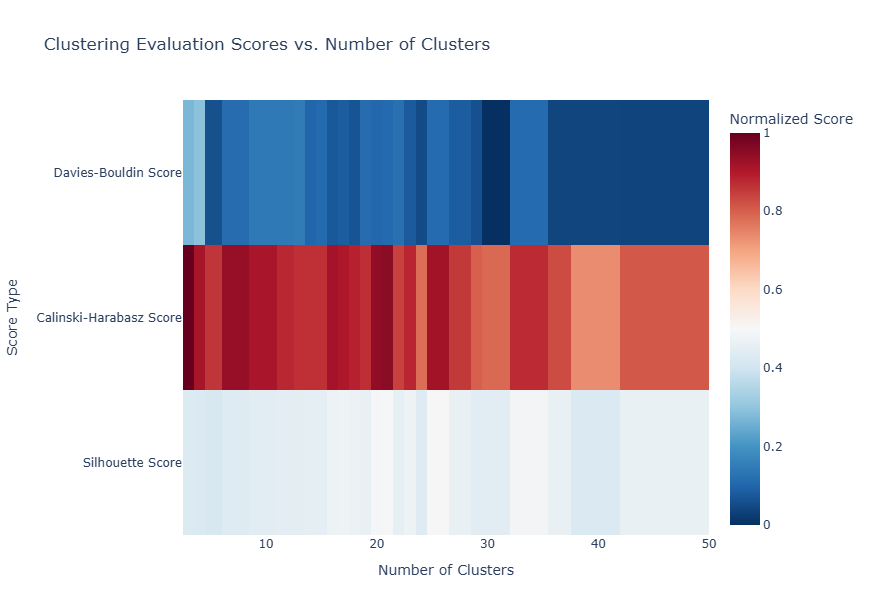

FileNotFoundError: [Errno 2] No such file or directory: 'images/heatmap_num_clusters_metrics.pdf'

In [43]:
def plot_clustering_scores_heatmap(df_scores):
    """
    Generates a heatmap of clustering evaluation scores (Silhouette, Calinski-Harabasz,
    Davies-Bouldin) against the number of clusters using Plotly.

    Args:
      df_scores: DataFrame containing clustering evaluation results with columns
                 'governo', 'depth_param', 'min_trajs_param', 'num_cluster',
                 'sil_score', 'ch_score', and 'db_score'.
    """
    # Group by number of clusters and calculate the mean of the scores
    df_grouped = df_scores.groupby('num_cluster')[['sil_score', 'ch_score', 'db_score']].mean().reset_index()

    # Melt the DataFrame to have scores as a single column for heatmap
    df_melted = df_grouped.melt(id_vars='num_cluster', var_name='score_type', value_name='score_value')

    # Normalize the scores for consistent coloring
    def normalize_score(row):
        if row['score_type'] == 'sil_score':
            # Silhouette: -1 to +1, higher is better. Normalize to 0-1 range.
            return (row['score_value'] + 1) / 2
        elif row['score_type'] == 'ch_score':
            # Calinski-Harabasz: 0 to +inf, higher is better. Use log scale and normalize.
            # Add a small value to avoid log(0)
            return np.log1p(row['score_value']) / np.log1p(df_melted[df_melted['score_type'] == 'ch_score']['score_value'].max())
        elif row['score_type'] == 'db_score':
            # Davies-Bouldin: 0 to +inf, lower is better. Invert and normalize.
            # Add a small value to avoid division by zero or large inverse values
            max_db = df_melted[df_melted['score_type'] == 'db_score']['score_value'].max()
            return 1 - (np.log1p(row['score_value']) / np.log1p(max_db))
        return row['score_value'] # Should not happen


    df_melted['normalized_score'] = df_melted.apply(normalize_score, axis=1)

    # Pivot back to create the heatmap matrix
    heatmap_data = df_melted.pivot_table(index='score_type', columns='num_cluster', values='normalized_score')

    # Order the score types for the heatmap rows
    score_order = ['sil_score', 'ch_score', 'db_score']
    heatmap_data = heatmap_data.reindex(score_order)

    # Create the heatmap using Plotly
    fig = go.Figure(data=go.Heatmap(
        z=heatmap_data.values,
        x=heatmap_data.columns,
        y=heatmap_data.index,
        colorscale='RdBu_r',  # Red-Blue reversed colorscale
        colorbar=dict(title='Normalized Score'),
        hovertemplate='Score Type: %{y}<br>Number of Clusters: %{x}<br>Normalized Score: %{z:.2f}<extra></extra>'
    ))

    fig.update_layout(
        title='Clustering Evaluation Scores vs. Number of Clusters',
        xaxis_title='Number of Clusters',
        yaxis_title='Score Type',
        yaxis=dict(tickmode='array', tickvals=score_order, ticktext=['Silhouette Score', 'Calinski-Harabasz Score', 'Davies-Bouldin Score']),
        width=1200,
        height=600
    )

    fig.show()
    fig.write_image("images/heatmap_num_clusters_metrics.pdf")


# Load the evaluation data
clustering_scores_pd = pd.read_csv("./preprocessing/governments_clustering_evaluation.csv")

# Filter for a specific government if needed (optional)
# filtered_scores = clustering_scores_pd[clustering_scores_pd['governo'] == 'Bolsonaro_1']

# Plot the heatmap
plot_clustering_scores_heatmap(clustering_scores_pd)

In [ ]:
def create_heatmap_v2(scores_pd):
  # Agrupar os dados por número de clusters e calcular a média dos scores
  grouped = scores_pd.groupby('num_cluster').agg({
      'sil_score': 'mean',
      'ch_score': 'mean',
      'db_score': 'mean'
  }).reset_index()

  # Ordenar por número de clusters
  grouped = grouped.sort_values('num_cluster')

  # Preparar os dados para o heatmap
  cluster_numbers = grouped['num_cluster'].astype(int).astype(str).tolist()
  metrics = ['sil_score', 'ch_score', 'db_score']
  metric_names = ['SS', 'CH', 'DB']

  # Para o heatmap, precisamos de uma matriz onde cada linha é uma métrica
  # e cada coluna é um número de cluster
  z_data = []

  for metric in metrics:
      z_data.append(grouped[metric].tolist())

  # Como as métricas têm escalas diferentes, normalizamos cada uma separadamente
  # para que todas fiquem na escala 0-1, onde 0 é o pior valor e 1 é o melhor
  z_normalized = []

  for i, metric in enumerate(metrics):
      if metric == 'db_score':
          # Para DB, valores menores são melhores, então invertemos a escala
          min_val = min(z_data[i])
          max_val = max(z_data[i])
          normalized = [(max_val - val) / (max_val - min_val) if max_val != min_val else 0 for val in z_data[i]]
      else:
          # Para Silhouette e CH, valores maiores são melhores
          min_val = min(z_data[i])
          max_val = max(z_data[i])
          normalized = [(max_val - val) / (max_val - min_val) if max_val != min_val else 0 for val in z_data[i]]

      z_normalized.append(normalized)

  # Criar o heatmap
  fig = go.Figure(data=go.Heatmap(
      z=z_normalized,
      x=cluster_numbers,
      y=metric_names,
      colorscale=[(0, 'darkblue'), (0.5, 'white'), (1, 'red')],
      colorbar=dict(title=dict(text="Normalized score (dark blue: worse; dark red: better)",
                         side="top"),                    
                    orientation="h",
                    x=0.5,       # centraliza
                    y=-0.25,     # coloca abaixo do gráfico
                    xanchor="center",
                    yanchor="top"),
      hoverongaps=False,
      hovertemplate='<b>%{y}</b><br>Number of clusters: %{x}<br>Real score: %{customdata}<br>Norm score: %{z}<extra></extra>',
      customdata=[[f"{val:.3f}" for val in row] for row in z_data]
  ))

  # Atualizar o layout
  fig.update_layout(
      # title='Desempenho dos Algoritmos de Clustering por Número de Clusters',
      xaxis_title='Number of clsuters',
      yaxis_title='Validity indices',
      width=800,
      height=300,
      margin=dict(l=0, r=0, t=5, b=0),
      xaxis=dict(automargin=True),
      yaxis=dict(automargin=True)
  )

  # Mostrar o gráfico
  fig.show()
  fig.write_image("images/heatmap_num_clusters_depth5.pdf")
  # plt.savefig(f'images/heatmap_num_clusters_metrics.pdf')

mask = (clustering_scores_pd['depth_param'] == 4) & (clustering_scores_pd['min_trajs_param'].isin([125,150,175]))
mask = (clustering_scores_pd['depth_param'] == 5) & (clustering_scores_pd['min_trajs_param'].isin([50]))
create_heatmap_v2(clustering_scores_pd[mask].copy())
# create_heatmap_v2(clustering_scores_pd.copy())

In [ ]:
def heatmap_depths_min_trajs(clustering_scores_pd):
  # Calcular a média dos scores para cada combinação de parâmetros
  grouped = clustering_scores_pd.groupby(['depth_param', 'min_trajs_param']).agg({
      'sil_score': 'mean',
      'ch_score': 'mean',
      'db_score': 'mean'
  }).reset_index()

  # Normalizar cada métrica individualmente (0 a 1, onde 1 é o melhor)
  for metric in ['sil_score', 'ch_score', 'db_score']:
      if metric == 'db_score':
          # Para DB, valores menores são melhores - inverter a escala
          min_val = grouped[metric].min()
          max_val = grouped[metric].max()
          grouped[f'{metric}_norm'] = (max_val - grouped[metric]) / (max_val - min_val)
      else:
          # Para Silhouette e CH, valores maiores são melhores
          min_val = grouped[metric].min()
          max_val = grouped[metric].max()
          grouped[f'{metric}_norm'] = (grouped[metric] - min_val) / (max_val - min_val)

  # Calcular uma pontuação composta (média das métricas normalizadas)
  grouped['composite_score'] = grouped[['sil_score_norm', 'ch_score_norm', 'db_score_norm']].mean(axis=1)

  # Preparar os dados para o heatmap
  depth_values = sorted(grouped['depth_param'].unique())
  min_traj_values = sorted(grouped['min_trajs_param'].unique())

  # Criar uma matriz para o heatmap
  z_data = np.zeros((len(min_traj_values), len(depth_values)))

  for idx, depth in enumerate(depth_values):
      for jdx, min_traj in enumerate(min_traj_values):
          # Encontrar o valor composto para esta combinação de parâmetros
          match = grouped[(grouped['depth_param'] == depth) & (grouped['min_trajs_param'] == min_traj)]
          if not match.empty:
              z_data[jdx, idx] = match['composite_score'].values[0]
          else:
              z_data[jdx, idx] = np.nan

  # Criar o heatmap
  fig = go.Figure(data=go.Heatmap(
      z=z_data,
      zmin=0,
      zmax=1,
      x=depth_values,
      y=min_traj_values,
      colorscale=[(0, 'darkblue'), (0.5, 'white'), (1, 'red')],
      colorbar=dict(title=dict(text="Normalized score (dark blue: worse; dark red: better)",
                         side="top"),
                    orientation="h",
                    x=0.5,       # centraliza
                    y=-0.25,     # coloca abaixo do gráfico
                    xanchor="center",
                    yanchor="top",
                    tickvals=[0, 0.25, 0.5, 0.75, 1],  # Valores onde os ticks aparecem
                    ticktext=['0', '0.25', '0.5', '0.75', '1']  # Texto personalizado
                    ),
      hoverongaps=False,
      hovertemplate='<b>Depth:</b> %{x}<br><b>Min Trajs:</b> %{y}<br><b>Pontuação:</b> %{z:.3f}<extra></extra>'
  ))

  # Atualizar o layout para remover espaços em branco
  fig.update_layout(
      # title='Desempenho de Clustering por Parâmetros (Média das Métricas)',
      xaxis_title='Depth',
      yaxis_title='Minimum Trajectories',
      width=800,
      height=300,
      autosize=False,
      xaxis=dict(#automargin=True,
                 tickmode='array',      # Modo array para especificar ticks manualmente
                 tickvals=depth_values, # Todos os valores do depth_param
                 ticktext=[str(d) for d in depth_values]),  # Margens automáticas para o eixo X
      yaxis=dict(#automargin=True,
                 tickmode='array',      # Modo array para especificar ticks manualmente
                 tickvals=min_traj_values, # Todos os valores do min_trajs_param
                 ticktext=[str(m) for m in min_traj_values]),
      margin=dict(l=0, r=5, t=5, b=0),
      paper_bgcolor="white",
      plot_bgcolor="white"
  )

  fig.update_xaxes(nticks=len(depth_values))   # Número de ticks = número de valores únicos
  fig.update_yaxes(nticks=len(min_traj_values))

  # Mostrar o gráfico
  fig.show()
  fig.write_image("images/heatmap_depth_min_trajs.pdf")
  # plt.savefig(f'images/heatmap_depth_min_trajs.pdf')

heatmap_depths_min_trajs(clustering_scores_pd)

### general

In [ ]:
def round_perc(numerator, denominator, decimals=2):
  return round((numerator / denominator) * 100, decimals)

In [ ]:
def compute_stats_df_period(df_:pd.DataFrame):
  """Compute some statsitics for the governments in the dataframe.
     INPUTS
     df_: dataframe with the data to evaluate.

     RETURNS
     df_stats: dataframe with the stats.
  """

  govs, qdt_parties, qtd_deputies, qtd_tids, qtd_votes, avg_tid_len, std_tid_len, dts_min, dts_max = [], [], [], [], [], [], [], [], []
  for gov in df_['governo'].unique():
    df_gov = df_[df_['governo'] == gov]
    govs.append(gov)
    qdt_parties.append(df_gov['partido'].nunique())
    qtd_deputies.append(df_gov['parlamentar'].nunique())
    qtd_tids.append(df_gov['tid'].nunique())
    qtd_votes.append(df_gov.shape[0])
    avg_tid_len.append(round(df_gov.groupby('tid').size().mean(),2))
    std_tid_len.append(round(df_gov.groupby('tid').size().std(),2))
    dts_min.append(pd.to_datetime(df_gov['data'].min().strftime('%d-%m-%Y')))
    dts_max.append(pd.to_datetime(df_gov['data'].max().strftime('%d-%m-%Y')))

  df_stats = pd.DataFrame({'governo':govs, 'qdt_parties':qdt_parties, 'qtd_deputies':qtd_deputies, 'qtd_tids':qtd_tids, 'qtd_votes':qtd_votes, 'avg_tid_len':avg_tid_len, 'std_tid_len':std_tid_len, 'date_min':dts_min, 'date_max':dts_max})
  df_stats.sort_values(by=['date_min'], ascending=[True], inplace=True)
  display(df_stats)

# compute_stats_df_period(df_bkp)

### vis

In [ ]:
def group_many_values_att(df_, attributes={}):
  """Method to group the attibute values with small quantities.
     INPUTS
     df_: dataframe with the data to evaluate.
     attributes: dict with list of attributes to group the values and threshold value.

     RETURNS
     df_: dataframe with the grouped values.
  """

  if len(attributes) > 0:
    for att in attributes['atts']:
      if df_[att].nunique() > attributes['thres']:
        gp = df_.groupby(att).size().reset_index(name='counts')
        total_counts = gp['counts'].sum()
        gp['percentage'] = round((gp['counts'] / total_counts) * 100, 2)
        gp = gp.sort_values(by='percentage', ascending=False)
        gp['cumulated_percentage'] = gp['percentage'].cumsum()

        at_least_80_perc = []
        for i, val in enumerate(gp['cumulated_percentage']):
          if val <= 80:
            at_least_80_perc.append(gp.iloc[i][att])
          else:
            at_least_80_perc.append(gp.iloc[i][att])
            break

        df_[att] = df_[att].apply(lambda x: x if x in at_least_80_perc else 'Outros')
  return df_

In [ ]:
def plot_sankey_flow(X, Y, L, node_label, split_strat, gov, lc={}, atts_to_gorup={}, width=1000, height=400):
  """
  Exibe um gráfico Sankey usando o plotly.

  Args:
    X: Dict com os DataFrames de cada nó.
    Y: DataFrame com os dados originais.
    L: Lista de nomes de colunas.
  """

  voto_concat = {'Sim':'Sim/Não', 'Não':'Sim/Não', 'Obstrução':'Obstrução', 'Abstenção':'Abstenção', 'Indefinido':'Indefinido'}

  fixed_colors = {# political spectrum
                  'Extrema-esquerda':'#BF4040', 'Esquerda':'red', 'Centro-esquerda':'#FFA4A4',
                  'Centro':'#80FF00', 'Centro-direita':'#A4BCFF', 'Direita':'#0044FF', 'Extrema-direita':'#001D6D', 'Indefinido':'#750D86',
                  # government alignment
                  'votou com o governo':'#1CA71C', 'votou contra o governo':'red', 'nao se aplica':'blue','indefinido':'orange',
                  # parties
                  'PT':'red', 'PSOL':'red', 'PSTU':'red', 'PSL':'blue', 'PL':'blue'
                 }

  # Get list of tids on cluster
  X = X[node_label]
  # Pega a lista de índices únicos em X
  unique_indices = X.index.unique().tolist()

  # Filtra o dataframe Y usando a coluna tid
  filtered_Y = Y[Y['tid'].isin(unique_indices)]    
  filtered_Y['voto'] = filtered_Y['voto'].map(voto_concat)

  # compute avg traj length
  gp_traj_len = filtered_Y.groupby('tid').size().reset_index(name='counts')
  avg_traj_len = round(gp_traj_len['counts'].mean(), 2)
  sd_traj_len  = round(gp_traj_len['counts'].std(), 2)

  # agrupar valores pequenos
  filtered_Y = group_many_values_att(filtered_Y.copy(), atts_to_gorup)

  n_tot_votes = len(filtered_Y)
  unique_deputies = filtered_Y['parlamentar'].unique().tolist()
  title_text = f"Node: {node_label}; Split: {split_strat}; Government: {gov}<br>"
  title_text += f"TIDs: {len(unique_indices)}; Unique deputies:{len(unique_deputies)}; Total votes: {n_tot_votes}"
  title_text += f"; avg_len: {avg_traj_len} &#x2213; {sd_traj_len}<br>"
  title_text += f"from {filtered_Y['data'].min().strftime('%Y-%m-%d')} to {filtered_Y['data'].max().strftime('%Y-%m-%d')}"
  title_text += f"; Highlight-view: {lc}"

  df_flows = filtered_Y.groupby(L, observed=True).size().reset_index(name='counts')
  df_flows['percentage'] = (df_flows['counts'] / n_tot_votes) * 100

  # Define os labels caso tenha chaves iguais para evitar loop
  labels = []
  new_labels = []
  id_iter_label = 0
  map_label_id = {}
  map_id_label = {}
  for col in L:
    values = filtered_Y[col].unique().tolist()
    labels.extend(values)
    for v in values:
      c_v = str(col)+"_"+str(v)
      if c_v not in map_label_id:
        map_label_id[c_v] = id_iter_label
        map_id_label[id_iter_label] = c_v
        new_labels.append(v)
        id_iter_label += 1
  labels = list(set(labels))

  # get totals of votes per feature value
  tot_att_val_votes = {}
  for col in L:
    att_values = filtered_Y[col].unique().tolist()
    for att_val in att_values:
      tot_att_val_votes[col+"_"+str(att_val)] = len(filtered_Y[filtered_Y[col] == att_val])

  # get flow and custom data
  source           = []
  target           = []
  flow_values      = []
  counts_custom    = []
  custom_perc_att  = []
  links_flow       = []
  for index, row in df_flows.iterrows():
    link = [row[col] for col in L]
    link = "->".join(link)
    for i in range(len(L) - 1):
      flow_values.append(row['percentage'])
      counts_custom.append(row['counts'])
      custom_perc_att.append(round(row['counts']/tot_att_val_votes[L[i+1]+"_"+str(row[L[i+1]])]*100,2))
      links_flow.append(link)
      source.append(map_label_id[L[i]+"_"+str(row[L[i]])])
      target.append(map_label_id[L[i+1]+"_"+str(row[L[i+1]])])

  # highlight specific links
  # links_color = ["lightgray"]*len(source)
  links_color = []
  if len(lc) > 0:
    for i, val in enumerate(links_flow):
      color = None
      color = get_link_color_party_alignment(view=lc, link_flow=val)
      # print(f"Link color={color}")
      # links_color[i] = color
      links_color.append(color)

      # for k, color in lc.items():
      #   if k in val:
      #     links_color[i] = color
      #     break


  # Cria o gráfico Sankey
  fig = go.Figure(data=[go.Sankey(
      # type="sankey",
      arrangement = 'snap',
      orientation = 'h',
      valueformat = ".2f",
      valuesuffix = "%",
      node = dict(
        pad = 15,
        thickness = 20,
        line = dict(color = "black", width = 0.5),
        # label = labels,
        label = new_labels,
        # color = "blue"
        color = "black"
      ),
      link = dict(
        source     = source,
        target     = target,
        value      = flow_values,
        customdata = np.transpose([counts_custom, custom_perc_att]),
        label      = links_flow,
        color      = links_color,
        # hovercolor=["red"]*len(source),
        hovercolor="red",
        hovertemplate='Source: %{source.label}<br />'+
                      'Target: %{target.label}<br />'+
                      '#_votes: %{customdata[0]}<br />'+
                      '%_flow: %{value}<br />'+
                      '%_flow_att: %{customdata[1]}%<br />'+
                      'Flow: %{label}<br /><extra></extra>',
      )
  )])

  fig.update_layout(title_text=title_text, font_size=10, width=width, height=height)
  fig.show()
  del X, Y

In [ ]:
def get_link_color_party_alignment(view:str, link_flow:str):
  # we group together neighbor spectrums to simplify, like: center-left and left as left
  esp_pol_party_color = {'esquerda':{'parties':['PCdoB','PT','PSOL','Cidadania','PV','PDT','PSB','Solidariedade','PPL','Rede'],
                                     'color':'red'},
                         'centro':{'parties':['MDB','PSD','PROS','Avante','PSDB'],
                                   'color':'#80FF00'},
                         'direita':{'parties':['PTB','PSC','Patriota','Novo','PRP','PSL','Republicanos','DEM','União','DC',
                                               'PP','PL','PHS','Podemos','PTC','PRB','PMN'],
                                    'color':'blue'}
                        }
  link_split = link_flow.split('->')

  if view == 'opposition':
    if (('votou contra o governo' in link_split) | ('Obstrução' in  link_split)):
      for esp in esp_pol_party_color.keys():
        for party in esp_pol_party_color[esp]['parties']:
          if party in link_split:
            return esp_pol_party_color[esp]['color']
      return 'orange'
    else:
      return 'lightgray'

  elif view == 'support':
    if (('votou contra o governo' not in link_split) & ('Obstrução' not in link_split)):
      for esp in esp_pol_party_color.keys():
        for party in esp_pol_party_color[esp]['parties']:
          if party in link_split:
            return esp_pol_party_color[esp]['color']
      return 'orange'
    else:
      return 'lightgray'
  else:
    print("Invalid view. Check the LC option: opposition/support. Returnung 'lightgray as default.'")
    return 'lightgray'

In [ ]:
# node_id = 'Lvl 5 - 2'

# lc = {
#       # 'votou contra o governo->Extrema-esquerda':'red',
#       # 'votou contra o governo->Esquerda':'red',
#       # 'votou contra o governo->Centro->':'#80FF00',
#       # 'votou contra o governo->Centro-direita->':'#A4BCFF',
#       # 'votou contra o governo->Direita':'blue',
#       # 'votou contra o governo->Extrema-direita':'blue',
#       'votou contra o governo->Sim->Extrema-esquerda->':'red',
#       'votou contra o governo->Não->Extrema-esquerda->':'red',
#       'votou contra o governo->Sim->Esquerda->':'red',
#       'votou contra o governo->Não->Esquerda->':'red',
#       'votou contra o governo->Sim->Centro-esquerda->':'red',
#       'votou contra o governo->Não->Centro-esquerda->':'red',

#       'votou contra o governo->Sim->Centro->':'#80FF00',
#       'votou contra o governo->Não->Centro->':'#80FF00',

#       'votou contra o governo->Sim->Centro-direita->':'blue',
#       'votou contra o governo->Não->Centro-direita->':'blue',
#       'votou contra o governo->Sim->Direita->':'blue',
#       'votou contra o governo->Não->Direita->':'blue',
#       'votou contra o governo->Sim->Extrema-direita->':'blue',
#       'votou contra o governo->Não->Extrema-direita->':'blue',

#       'nao se aplica->Obstrução->Extrema-esquerda->':'red',
#       'nao se aplica->Obstrução->Esquerda->':'red',
#       'nao se aplica->Obstrução->Centro-esquerda->':'red',

#       'nao se aplica->Obstrução->Centro->':'#80FF00',

#       'nao se aplica->Obstrução->Centro-direita->':'blue',
#       'nao se aplica->Obstrução->Direita->':'blue',
#       'nao se aplica->Obstrução->Extrema-direita->':'blue',
#       }


# # plot_sankey_flow(TreeNode.df_dict.copy(), df.copy(), ['governo', 'alinhamento', 'voto', 'partido', 'tipoProposicao'], node_id, strat_split,
# #                  name_test_government, lc=lc, atts_to_gorup={'atts': ['partido','tipoProposicao'], 'thres': 10}, width=1100, height=600)

# plot_sankey_flow(TreeNode.df_dict.copy(), df.copy(), ['governo', 'alinhamento', 'voto', 'partido', 'tipoProposicao'], node_id, strat_split,
#                  name_test_government, lc='support', atts_to_gorup={'atts': ['partido','tipoProposicao'], 'thres': 10}, width=1100, height=600)

In [ ]:
def plot_treemap_cluster(df_origin: pd.DataFrame, df_clusters: dict, node_id: str, aspects: list):
  voto_concat = {'Sim':'Sim/Não', 'Não':'Sim/Não', 'Obstrução':'Obstrução', 'Abstenção':'Abstenção', 'Indefinido':'Indefinido'}
  df_cluster = df_clusters[node_id][aspects]
  df_origin = df_origin[aspects]

  if 'voto' in aspects:
    df_cluster['voto'] = df_cluster['voto'].map(voto_concat)
    df_origin['voto'] = df_origin['voto'].map(voto_concat)

  tot_votes = len(df_cluster)
  mask_not_inline = ((df_cluster['alinhamento'] == 'votou contra o governo') | (df_cluster['voto'] == 'Obstrução'))
  qtd_not_inline = len(df_cluster[mask_not_inline])
  if qtd_not_inline/tot_votes >= 0.5:
    color = "reds"
  else:
    color = "blues"

  aspects_list        = []
  aspects_values_list = []
  qtd_asp_value_list  = []
  qtd_asp_value_tot   = []
  for asp in aspects:
    unique_asp_values = df_cluster[asp].unique().tolist()
    for val in unique_asp_values:
      aspects_list.append(asp)
      aspects_values_list.append(val)
      qtd_asp_value_list.append(len(df_cluster[df_cluster[asp] == val]))
      qtd_asp_value_tot.append(len(df_origin[df_origin[asp] == val]))

  df_treemap = pd.DataFrame({'aspect':aspects_list, 'aspect_value':aspects_values_list, '#_votes_cluster':qtd_asp_value_list,
                             '#_votes_tot':qtd_asp_value_tot})

  lambda_ = lambda x: round_perc(x['#_votes_cluster'], df_treemap[df_treemap['aspect']==x['aspect']]['#_votes_cluster'].sum())
  df_treemap['%_asp_value_cluster'] = df_treemap.apply(lambda_, axis=1)
  lambda_ = lambda x: round_perc(x['#_votes_cluster'], df_treemap[df_treemap['aspect']==x['aspect']]['#_votes_tot'].sum())
  df_treemap['%_asp_value_tot']     = df_treemap.apply(lambda_,axis=1)

  fig = px.treemap(df_treemap, path=[px.Constant(f"Cluster:{node_id}"), 'aspect', 'aspect_value'], values='#_votes_cluster',
                   hover_data=['%_asp_value_tot'], color='%_asp_value_cluster',
                   color_continuous_scale=color, # RdBu, reds, blues, thermal, orrd
                   color_continuous_midpoint=50,
                   )
  fig.update_traces(root_color="lightgrey")
  fig.update_coloraxes(colorbar=dict(x=0.4, y=1.05, len=0.8, orientation='h'))
  fig.update_layout(margin = dict(t=50, l=25, r=25, b=25), width=1000)
  fig.show()

In [ ]:
plot_treemap_cluster(df.copy(), TreeNode.df_leaves.copy(), 'Lvl 5 - 0', ['alinhamento', 'partido', 'tipoProposicao','voto'])

In [ ]:
def plot_parallel_coordinates_go(df: pd.DataFrame, government: str):
  """
  Plots a parallel coordinates graph using plotly.graph_objects for clustering evaluation metrics,
  filtered by a specific government, with custom sorting and coloring.

  Args:
    df: DataFrame containing clustering evaluation results.
    government: String specifying the government to filter by.
  """
  df_gov = df[df['governo'] == government].copy()

  if df_gov.empty:
    print(f"No data found for government: {government}")
    return

  # Define dimensions and their sorting
  dimensions = [
      dict(range=[df_gov['depth_param'].min(), df_gov['depth_param'].max()],
           constraintrange = [1, 10],
           label='depth_param', values=df_gov['depth_param'], tickvals=df_gov['depth_param'].unique()),
      dict(range=[df_gov['min_trajs_param'].min(), df_gov['min_trajs_param'].max()],
           label='min_trajs_param', values=df_gov['min_trajs_param'], tickvals=df_gov['min_trajs_param'].unique()),
      dict(range=[df_gov['num_cluster'].min(), df_gov['num_cluster'].max()],
           label='num_cluster', values=df_gov['num_cluster'], tickvals=df_gov['num_cluster'].unique()),
      dict(range=[df_gov['sil_score'].min(), df_gov['sil_score'].max()],
           constraintrange = [-0.03, 1],
           label='sil_score', values=df_gov['sil_score']),
      dict(range=[df_gov['ch_score'].min(), df_gov['ch_score'].max()],
           constraintrange = [250,df_gov['ch_score'].max()],
           label='ch_score', values=df_gov['ch_score']),
      dict(range=[df_gov['db_score'].max(), df_gov['db_score'].min()],
           label='db_score',
          #  values=df_gov[['db_score']].sort_values(by='db_score', ascending=True)['db_score']
           values=df_gov['db_score']
           )
  ]

  fig = go.Figure(data=
    go.Parcoords(
        line = dict(#color = df_gov['num_cluster'],
                    color = 'red',
                   colorscale = 'Viridis',
                   showscale = True,
                   cmin = df_gov['num_cluster'].min(),
                   cmax = df_gov['num_cluster'].max()
                  # multiselect=True,          # <<< SOLUÇÃO PRINCIPAL
                  # line_restriction='inside'  # Linhas devem estar em TODAS seleções
                  ),
        dimensions = dimensions
    )
  )

  fig.update_layout(
      title=f'Clustering Evaluation for {government}',
      plot_bgcolor = 'white',
      paper_bgcolor = 'white',
      height=400,
      width=1000,
      # Configuração essencial para seleção múltipla:
      dragmode='select',
      selectdirection='h'
  )

  fig.show()

# Example usage (assuming 'data_clustering_evaluation_pd' is the DataFrame from run_internal_evaluations)
data_clus_eval = pd.read_csv("./preprocessing/governments_clustering_evaluation.csv")
plot_parallel_coordinates_go(data_clus_eval, 'Temer_1')

### stats

In [ ]:
def show_intersection_info_clusters(node_x: str, node_y: str, df_origin: pd.DataFrame, df_clusters):
  """Method to show information considering the intersetion between two nodes.

     INPUTS:
     node_x: str, name of the first node that is going to be used as reference.
                  Ex: set(node_x).intersection(set(node_y))
     node_y: str, name of the second node.
     df_origin: pd.DataFrame, dataframe with the data loaded.

     RETURNS: NONE
  """
  tids_x = df_clusters[node_x]['tid'].unique().tolist()
  deputies_x = df_origin[df_origin['tid'].isin(tids_x)]['parlamentar'].unique().tolist()

  tids_y = df_clusters[node_y]['tid'].unique().tolist()
  deputies_y = df_origin[df_origin['tid'].isin(tids_y)]['parlamentar'].unique().tolist()

  dep_intersect = list(set(deputies_x).intersection(set(deputies_y)))


  diff_x = list(set(deputies_x).difference(set(dep_intersect)))
  diff_y = list(set(deputies_y).difference(set(dep_intersect)))
  if len(diff_x) < len(diff_y):
    dep_diff = diff_x
    node_diff = node_x
  else:
    dep_diff = diff_y
    node_diff = node_y

  df_diff = df_origin[df_origin['parlamentar'].isin(dep_diff)]
  gp_diff = df_diff.groupby(['parlamentar','partido','esp_pol_partido']).agg({'tid':'nunique'}) \
                   .reset_index().rename(columns={'tid':'tot_tid'})
  lambda_ = lambda x: df_origin[df_origin['parlamentar'] == x['parlamentar']] \
            .groupby(['tid']).size() \
            .reset_index(name='traj_length')['traj_length'].mean()
  gp_diff['avg_len_tid_tot'] = gp_diff.apply(lambda_, axis=1)
  df_cluster = df_clusters[node_diff]
  lambda_ = lambda x: df_cluster[df_cluster['parlamentar'] == x['parlamentar']]['tid'].nunique()
  gp_diff['#_tid_cluster']   = gp_diff.apply(lambda_, axis=1)
  lambda_ = lambda x: df_cluster[df_cluster['parlamentar'] == x['parlamentar']] \
            .groupby(['tid']).size() \
            .reset_index(name='traj_length')['traj_length'].mean()
  gp_diff['avg_len_tid_cluster'] = gp_diff.apply(lambda_, axis=1)

  gp_esp_pol = gp_diff.groupby(['esp_pol_partido']).size().reset_index(name='#_dep_esp_pol')
  gp_esp_pol['%_size'] = round(gp_esp_pol['#_dep_esp_pol'] / gp_esp_pol['#_dep_esp_pol'].sum() * 100, 2)
  gp_esp_pol = gp_esp_pol.sort_values(by='%_size', ascending=False)

  print(f"TIDS node {node_x}: {len(tids_x)}")
  print(f"TIDS node {node_y}: {len(tids_y)}")
  print(f"Deputies node {node_x}: {len(deputies_x)}")
  print(f"Deputies node {node_y}: {len(deputies_y)}")
  print(f"Deputies intersection between nodes: {len(dep_intersect)}")
  print(f"Smallest diff intersection with node '{node_diff}': {len(dep_diff)}")

  display(gp_diff)
  display(gp_esp_pol)

In [ ]:
def __get_max_votes_period(date, df_origin):
  month = date.month
  year  = date.year
  df_filter = df_origin[df_origin['data'].dt.year == year].copy()
  if month >= 1 and month <= 6:
    mask = (df_origin['data'].dt.month >= 1) & (df_origin['data'].dt.month <= 6)
  else:
    mask = (df_origin['data'].dt.month >= 7) & (df_origin['data'].dt.month <= 12)

  df_filter = df_filter[mask][['tid','data','parlamentar']].drop_duplicates()

  return df_filter[['tid']].groupby(by=['tid']).size().reset_index(name='#_votes')['#_votes'].max()

def __get_avg_presence_cluster(df_cluster, df_origin):
  df_gp = df_cluster[['tid','data']].groupby(by=['tid']).agg(n_votes=('tid','size'), min_date=('data','min'), max_date=('data','max'))
  df_gp['max_votes_period'] = df_gp.apply(lambda x: __get_max_votes_period(x['max_date'], df_origin), axis=1)
  df_gp['presence'] = round(df_gp['n_votes'] / df_gp['max_votes_period'] * 100, 2)
  if len(df_gp) > 1:
    return round(df_gp['presence'].mean(),2), round(df_gp['presence'].std(),2)
  else:
    return round(df_gp['presence'].values[0],2), None


In [ ]:
def __sub_stats_traj_details_deps_cluster(df_cluster:pd.DataFrame, df_clusters:dict, df_origin:pd.DataFrame):
  df_cluster = df_cluster.sort_values(by=['data','governo','partido'])
  deps = df_cluster['parlamentar'].unique().tolist()

  data = []
  for dep in deps:
    ## looking for data in other clusters
    tot_tids_dep = df_origin[df_origin['parlamentar']==dep]['tid'].nunique()

    ## looking at the specific cluster
    df_dep = df_cluster[df_cluster['parlamentar'] == dep].copy()
    party = df_dep['partido'].unique()[-1]
    esp_pol = df_dep['esp_pol_partido'].unique()[-1]
    n_tids = df_dep['tid'].nunique()
    traj_len_avg = df_dep.groupby('tid').size().mean()
    traj_lev_std = round(df_dep.groupby('tid').size().std(),2) if n_tids > 1 else 0
    # print(f"\t\t- Dep: {dep} {party} -> Num_tids: {n_tids}; TIDs_avg_len: {traj_len_avg}\u00B1{traj_lev_std}")

    tids   = df_dep['tid'].unique().tolist()
    for tid in tids:
      df_dep_tid = df_dep[df_dep['tid'] == tid]
      mask = (df_dep_tid['alinhamento']=='votou contra o governo') | (df_dep_tid['voto']=='Obstrução')
      vote_in_line = False if len(df_dep_tid[mask]) > 0 else True
      gov = df_dep_tid['governo'].unique()
      tid_len = len(df_dep_tid)
      tid_min_date = df_dep_tid['data'].min()
      tid_max_date = df_dep_tid['data'].max()
      max_votes_period = __get_max_votes_period(tid_max_date, df_origin)
      presence = round(tid_len/max_votes_period*100,2)
      row = [gov, dep, esp_pol, party, tot_tids_dep, n_tids, tid, tid_len, max_votes_period, presence, vote_in_line, tid_min_date, tid_max_date]
      data.append(row)
      # print(f"\t\t\t-- TID_{tid} -> #_votes: {tid_len}; Data: {tid_min_date.strftime('%Y-%m-%d')} to {tid_max_date.strftime('%Y-%m-%d')}; Government: {gov}; max_votes_period: {_max_votes_period}")

  df_res = pd.DataFrame(data=data, columns=['governo', 'parlamentar', 'esp_pol', 'partido', 'tot_tids_dep', 'n_tids_cluster', 'tid', 'tid_len_cluster', 'max_votes_period', 'presence_%', 'in-line?','tid_min_date','tid_max_date'])
  df_res = df_res.sort_values(by=['tid_min_date','parlamentar','partido'])
  print(f"\t\t- TID avg length cluster: {round(df_res['tid_len_cluster'].mean(),2)}\u00B1{round(df_res['tid_len_cluster'].std(),2)}")

  # display(df_res[df_res['presence_%']>=100])

  df_tmp = df_res[df_res['in-line?'] == False].copy()
  if len(df_res) <= 11:
    print(f"\t\t- avg_tot_tids_deps:{round(df_tmp['tot_tids_dep'].mean(),2)}\u00B1{round(df_tmp['tot_tids_dep'].std(),2)}; deputies: {df_tmp['parlamentar'].nunique()}")
    display(df_res)
  else:
    print(f"\t\t- original dataframe size:{df_res.shape[0]}",end="; ")
    print(f" new dataframe size:{df_tmp.shape[0]}; avg_tot_tids_deps:{round(df_tmp['tot_tids_dep'].mean(),2)}\u00B1{round(df_tmp['tot_tids_dep'].std(),2)}; deputies: {df_tmp['parlamentar'].nunique()}")
    display(df_tmp.head(11))

  print(f"\t\t- number of votes NOT inline by year/semester. ",end='')
  years = df_cluster.sort_values(by=['data'])['data'].dt.year.unique()
  mask_not_inline = (df_cluster['alinhamento'] == 'votou contra o governo') | (df_cluster['voto'] == 'Obstrução')
  t_v_nil = df_cluster[mask_not_inline].shape[0]
  print(f" Total: {t_v_nil}")
  for year in years:
    df_year = df_cluster[(df_cluster['data'].dt.year == year) & mask_not_inline].copy()
    mask_1s = (df_year['data'].dt.month >= 1) & (df_year['data'].dt.month <= 6)
    mask_2s = (df_year['data'].dt.month >= 7) & (df_year['data'].dt.month <= 12)
    qtd_1s = len(df_year[mask_1s])
    qtd_2s = len(df_year[mask_2s])
    if t_v_nil > 0:
      print(f"\t\t\tYear: {year} ->\tDataset 1° semester: {qtd_1s} ({round(qtd_1s/t_v_nil*100,2)}%); 2° semester: {qtd_2s}({round(qtd_2s/t_v_nil*100,2)})%")
    else:
      print(f"\t\t\tYear: {year} ->\tDataset 1° semester: {qtd_1s}; 2° semester: {qtd_2s}")

  print(f"\t\t- info parties (not-inline)")
  parties_not_inline = df_tmp['partido'].unique().tolist() # only not-inline
  info_parties_dep_not_inline = df_origin[df_origin['partido'].isin(parties_not_inline)].groupby(['partido', 'esp_pol_partido']).agg({'parlamentar':'nunique'}).reset_index().rename(columns={'parlamentar':'tot_deps'})
  info_parties_dep_not_inline['#_deps_cluster'] = info_parties_dep_not_inline['partido'].apply(lambda x: len(df_tmp[df_tmp['partido'] == x].drop_duplicates(subset=['parlamentar'])))
  info_parties_dep_not_inline['%_deps_cluster'] = round(info_parties_dep_not_inline['#_deps_cluster'] / info_parties_dep_not_inline['tot_deps'] * 100, 2)
  info_parties_dep_not_inline['votes_cluster'] = info_parties_dep_not_inline['partido'].apply(lambda x: df_tmp[df_tmp['partido'] == x]['tid_len_cluster'].sum())
  info_parties_dep_not_inline['%_votes'] = round(info_parties_dep_not_inline['votes_cluster'] / info_parties_dep_not_inline['votes_cluster'].sum() * 100, 2)
  display(info_parties_dep_not_inline.head(40))

  print(f"\t\t- info parties (inline & not-inline)")
  parties_all = df_res['partido'].unique().tolist() # all
  info_parties_all = df_origin[df_origin['partido'].isin(parties_all)].groupby(['partido', 'esp_pol_partido']).agg({'parlamentar':'nunique'}).reset_index().rename(columns={'parlamentar':'tot_deps'})
  info_parties_all['#_deps_cluster'] = info_parties_all['partido'].apply(lambda x: len(df_res[df_res['partido'] == x].drop_duplicates(subset=['parlamentar'])))
  info_parties_all['%_deps_cluster'] = round(info_parties_all['#_deps_cluster'] / info_parties_all['tot_deps'] * 100, 2)
  info_parties_all['votes_cluster'] = info_parties_all['partido'].apply(lambda x: df_res[df_res['partido'] == x]['tid_len_cluster'].sum())
  info_parties_all['%_votes'] = round(info_parties_all['votes_cluster'] / info_parties_all['votes_cluster'].sum() * 100, 2)
  display(info_parties_all.head(40))

In [ ]:
def __votes_in_line_cluster(df_cluster:pd.DataFrame, df_clusters:dict, df_origin:pd.DataFrame):

  print(f"\t- number of votes INLINE by year/semester. ",end='')
  years = df_cluster.sort_values(by=['data'])['data'].dt.year.unique()
  mask_not_inline = ((df_cluster['alinhamento'] == 'votou contra o governo') | (df_cluster['voto'] == 'Obstrução'))
  tot_votes = len(df_cluster)
  t_v_il = df_cluster[~mask_not_inline].shape[0]
  print(f" Total: {t_v_il} ({round_perc(t_v_il, tot_votes, 2)})%")
  for year in years:
    df_year = df_cluster[(df_cluster['data'].dt.year == year) & (~mask_not_inline)].copy()
    mask_1s = (df_year['data'].dt.month >= 1) & (df_year['data'].dt.month <= 6)
    mask_2s = (df_year['data'].dt.month >= 7) & (df_year['data'].dt.month <= 12)
    qtd_1s = len(df_year[mask_1s])
    qtd_2s = len(df_year[mask_2s])
    if t_v_il > 0:
      print(f"\t\tYear: {year} ->\tDataset 1° semester: {qtd_1s} ({round(qtd_1s/t_v_il*100,2)}%); 2° semester: {qtd_2s}({round(qtd_2s/t_v_il*100,2)})%")
    else:
      print(f"\t\tYear: {year} ->\tDataset 1° semester: {qtd_1s}; 2° semester: {qtd_2s}")


In [ ]:
def stats_cluster_trajs_votes(df_origin, df_clusters, node_id):
  df_cluster = df_clusters[node_id]
  deputies_names = df_cluster['parlamentar'].unique().tolist()
  deputies_tot_votes = {}
  tot_votes_cluster = len(df_cluster)

  num_tids_dep_by_gov = df_origin.groupby(['governo','parlamentar']).agg({'tid':'nunique'}) \
                                 .reset_index().rename(columns={'tid':'#_tids'})
  avg_tids_dep_by_gov = round(num_tids_dep_by_gov['#_tids'].mean(), 2)
  sd_tids_dep_by_gov  = round(num_tids_dep_by_gov['#_tids'].std(), 2)
  # num_tids_dep_by_gov.hist(figsize=(10, 3), bins=20)
  # plt.show()
  traj_len_by_gov = df_origin.groupby(['governo','tid']).size().reset_index(name='traj_length')
  avg_traj_len_by_gov = round(traj_len_by_gov['traj_length'].mean(), 2)
  sd_traj_len_by_gov  = round(traj_len_by_gov['traj_length'].std(), 2)

  tmp_df = df_origin[df_origin['parlamentar'].isin(deputies_names)]
  for dep in deputies_names:
    deputies_tot_votes[dep] = tmp_df[tmp_df['parlamentar'] == dep]['tid'].nunique()

  gp_tmp = tmp_df.groupby(['tid']).size().reset_index(name='traj_length')
  avg_traj_len = round(gp_tmp['traj_length'].mean(), 2)
  sd_traj_len  = round(gp_tmp['traj_length'].std(), 2)

  print("Considering the whole dataset:")
  print(f"\t- Government's occurrence: {df_origin['governo'].unique()}")
  print(f"\t- The avg number os tids per dep in each government: {avg_tids_dep_by_gov}\u00B1{sd_tids_dep_by_gov}")
  print(f"\t\t- The avg traj length in each government: {avg_traj_len_by_gov}\u00B1{sd_traj_len_by_gov}")
  print(f"\t- The avg number of trajs for the deps in the cluster: {np.mean(list(deputies_tot_votes.values())).round(2)}\u00B1{np.std(list(deputies_tot_votes.values())).round(2)}")
  print(f"\t\t- The avg traj length for the deps in the cluster: {avg_traj_len}\u00B1{sd_traj_len}")

  gp_deps_party = df_cluster.groupby(['partido'], observed=True).agg({'parlamentar':'nunique'}) \
                   .reset_index().rename(columns={'parlamentar':'#_dep'})

  gp_cluster = df_cluster.groupby(['parlamentar'], observed=True).agg({'tid':'nunique'}) \
                         .reset_index().rename(columns={'tid':'#_tids_cluster'})
  gp_cluster['tot_tids_dep'] = gp_cluster['parlamentar'].map(deputies_tot_votes)
  gp_cluster['%_cluster_deps'] = round((gp_cluster['#_tids_cluster'] / gp_cluster['tot_tids_dep']) * 100, 2)

  gp_traj_len_cluster  = df_cluster.groupby(['tid']).size().reset_index(name='traj_length')
  avg_traj_len_cluster = round(gp_traj_len_cluster['traj_length'].mean(), 2)
  sd_traj_len_cluster  = round(gp_traj_len_cluster['traj_length'].std(), 2)

  # compute representativeness of left and right parties in the cluster that does not voted in line (nil) with government
  aligment_mask          = (df_cluster['alinhamento']=='votou contra o governo') | (df_cluster['voto']=='Obstrução')
  n_r                    = len(df_cluster[aligment_mask])
  n_votes_nil_government = n_r if n_r > 0 else 0.000000001
  ex_left_nil            = len(df_cluster[aligment_mask & (df_cluster['esp_pol_partido']=='Extrema-esquerda')])
  left_nil               = len(df_cluster[aligment_mask & (df_cluster['esp_pol_partido']=='Esquerda')])
  c_left_nil             = len(df_cluster[aligment_mask & (df_cluster['esp_pol_partido']=='Centro-esquerda')])
  center_nil             = len(df_cluster[aligment_mask & (df_cluster['esp_pol_partido']=='Centro')])
  c_right_nil            = len(df_cluster[aligment_mask & (df_cluster['esp_pol_partido']=='Centro-direita')])
  right_nil              = len(df_cluster[aligment_mask & (df_cluster['esp_pol_partido']=='Direita')])
  ex_right_nil           = len(df_cluster[aligment_mask & (df_cluster['esp_pol_partido']=='Extrema-direita')])


  avg_presence_c, std_presence_c = __get_avg_presence_cluster(df_cluster, df_origin)
  cv = round(std_presence_c/avg_presence_c*100,2) if std_presence_c != None else '-'
  if cv != '-':
    cat_cv = 'baixa' if (cv <= 10) else 'média' if (cv>10 and cv<=20) else 'alta' if (cv>20 and cv<=30) else 'muito alta'
  else:
    cat_cv = '-'

  print(f"\nConsidering the cluster (Deps: {len(deputies_names)}; TIDs: {df_cluster['tid'].nunique()}; Votes: {df_cluster.shape[0]}); avg_presence_%: {avg_presence_c}\u00B1{std_presence_c}; CV%: {cv}% ({cat_cv})")
  print(f"\t- Government's occurrence: {df_cluster['governo'].unique()}")
  df_party_occur = df_cluster.drop_duplicates(subset=['partido','esp_pol_partido'])
  print(f"\t- Parties' occurrence: Uniques ({len(df_party_occur)}) {[row['partido']+'('+row['esp_pol_partido']+')' for i, row in df_party_occur.iterrows()]}")
  print(f"\t- Number deps_party: {[row['partido']+'('+str(row['#_dep'])+')' for i, row in gp_deps_party.iterrows()]}")
  print(f"\t- The avg number of tids per dep: {round(gp_cluster['#_tids_cluster'].mean(),2)}\u00B1{round(gp_cluster['#_tids_cluster'].std(),2)}. ", end='')
  print(f"It represents in percent: {round(gp_cluster['%_cluster_deps'].mean(),2)}%\u00B1{round(gp_cluster['%_cluster_deps'].std(),2)}% of the total tids of the deps in the cluster.")
  print(f"\t- The avg traj length in the cluster: {avg_traj_len_cluster}\u00B1{sd_traj_len_cluster}")
  __votes_in_line_cluster(df_cluster.copy(), df_clusters.copy(), df_origin.copy())
  print(f"\t- Votes not in line with government: {round(n_votes_nil_government,0)} ({round((n_votes_nil_government/tot_votes_cluster)*100,2)}%)")
  print("\t\t- Political spectrum")
  print(f"\t\t\t- Extreme-left: {ex_left_nil}, Cluster_%:{round_perc(ex_left_nil, tot_votes_cluster)}%, Not_in_line: {round_perc(ex_left_nil, n_votes_nil_government)}%")
  print(f"\t\t\t- Left: {left_nil}, Cluster_%: {round_perc(left_nil, tot_votes_cluster)}%, Not_in_line: {round_perc(left_nil, n_votes_nil_government)}%")
  print(f"\t\t\t- Center-left: {c_left_nil}, Cluster_%: {round_perc(c_left_nil, tot_votes_cluster)}%, Not_in_line: {round_perc(c_left_nil, n_votes_nil_government)}%")
  print(f"\t\t\t- Center: {center_nil}, Cluster_%: {round_perc(center_nil, tot_votes_cluster)}%, Not_in_line: {round_perc(center_nil, n_votes_nil_government)}%")
  print(f"\t\t\t- Center-right: {c_right_nil}, Cluster_%: {round_perc(c_right_nil, tot_votes_cluster)}%, Not_in_line: {round_perc(c_right_nil, n_votes_nil_government)}%")
  print(f"\t\t\t- Right: {right_nil}, Cluster_%: {round_perc(right_nil,tot_votes_cluster)}%, Not_in_line: {round_perc(right_nil,n_votes_nil_government)}%")
  print(f"\t\t\t- Extreme-right: {ex_right_nil}, Cluster_%: {round_perc(ex_right_nil,tot_votes_cluster)}%, Not_in_line: {round_perc(ex_right_nil,n_votes_nil_government)}%")
  __sub_stats_traj_details_deps_cluster(df_cluster.copy(), df_clusters.copy(), df_origin.copy())

## test
# id = 'Lvl 2 - 0'
# id = 'Lvl 3 - 0'
id = 'Lvl 4 - 1'
# id = 'Lvl 5 - 0'
# id = 'Lvl 5 - 1'
# id = 'Lvl 5 - 2'
# id = 'Lvl 5 - 3'
# id = 'Lvl 5 - 4'
# id = 'Lvl 5 - 5'

# stats_cluster_trajs_votes(df.copy(), TreeNode.df_leaves.copy(), id)

In [ ]:
# mask = (df['data'].dt.year == 2021) & ((df['data'].dt.month >= 1) & (df['data'].dt.month <= 6))
# mask = (df['data'].dt.year == 2021) & ((df['data'].dt.month >= 7) & (df['data'].dt.month <= 12))
# # mask = (df['data'].dt.year == 2020) & ((df['data'].dt.month >= 7) & (df['data'].dt.month <= 12
# df[mask][['tid']].groupby(by=['tid']).size().reset_index(name='#_votes')['#_votes'].max()

In [ ]:
def compute_support_votes_perc(df_: pd.DataFrame):
  governments = df_['governo'].unique().tolist()
  mask_sup = ((df_['alinhamento'] == 'votou com o governo')
              # | ((df_['alinhamento'] == 'nao se aplica') & ~(df_['voto'].isin(['Obstrução','Abstenção'])))
             )

  for gov in governments:
    df_tmp = df_[df_['governo'] == gov]
    tot_votes = df_tmp.shape[0]
    tot_sup   = df_tmp[mask_sup].shape[0]
    perc_sup  = round((tot_sup / tot_votes) * 100, 2)

    print(f"{gov} government - Supporting: {perc_sup}% ({tot_sup}), Opposition: {(100-perc_sup):.2f}% ({tot_votes-tot_sup})")

In [ ]:
# compute_support_votes_perc(df.copy())

## Sankey

### basic sankey

In [ ]:
def display_sankey(X, Y, L, node_label, split_strat):
  """
  Exibe um gráfico Sankey usando o plotly.

  Args:
    X: Dict com os DataFrames de cada nó.
    Y: DataFrame com os dados originais.
    L: Lista de nomes de colunas.
  """

  X = X[node_label]

  # Pega a lista de índices únicos em X
  unique_indices = X.index.unique().tolist()

  # Filtra o dataframe Y usando a coluna tid
  filtered_Y = Y[Y['tid'].isin(unique_indices)]

  # agrupar valores pequenos
  for col in ['partido', 'tipoProposicao']:
    gp = filtered_Y.groupby(col).size().reset_index(name='counts')
    if gp.shape[0] <= 6:
      break
    total_counts = gp['counts'].sum()
    gp['percentage'] = round((gp['counts'] / total_counts) * 100, 2)
    gp = gp.sort_values(by='percentage', ascending=False)
    gp['cumulated_percentage'] = gp['percentage'].cumsum()

    at_least_80_perc = []
    for i, val in enumerate(gp['cumulated_percentage']):
      if val <= 80:
        at_least_80_perc.append(gp.iloc[i][col])
      else:
        at_least_80_perc.append(gp.iloc[i][col])
        break

    filtered_Y[col] = filtered_Y[col].apply(lambda x: x if x in at_least_80_perc else 'Outros')

  n_tot_votes = len(filtered_Y)
  unique_deputies = filtered_Y['parlamentar'].unique().tolist()
  title_text = f"Node: {node_label}; Split: {split_strat}<br>TIDs: {len(unique_indices)}; Unique deputies:{len(unique_deputies)}; Total votes: {n_tot_votes}.<br>"
  title_text += f"from {filtered_Y['data'].min().strftime('%Y-%m-%d')} to {filtered_Y['data'].max().strftime('%Y-%m-%d')}"

  # Calcula o volume do flow (em porcentagem)
  flow_values = []
  counts_custom = []
  for i in range(len(L) - 1):
    temp = filtered_Y.groupby([L[i], L[i + 1]]).size().reset_index(name='counts')
    # total_counts = temp.groupby(L[i])['counts'].sum().reset_index(name='total_counts')
    # temp = temp.merge(total_counts, on=L[i])
    # temp['percentage'] = (temp['counts'] / temp['total_counts']) * 100
    temp['percentage'] = (temp['counts'] / n_tot_votes) * 100
    flow_values.extend(temp['percentage'].tolist())
    counts_custom.extend(temp['counts'].tolist())

  # Define os labels caso tenha chaves iguais para evitar loop
  labels = []
  new_labels = []
  id_iter_label = 0
  map_label_id = {}
  map_id_label = {}
  for col in L:
    values = filtered_Y[col].unique().tolist()
    labels.extend(values)
    for v in values:
      c_v = str(col)+"_"+str(v)
      if c_v not in map_label_id:
        map_label_id[c_v] = id_iter_label
        map_id_label[id_iter_label] = c_v
        new_labels.append(v)
        id_iter_label += 1
  labels = list(set(labels))

  # Define o source e o target
  source = []
  target = []
  links   = []
  for i in range(len(L) - 1):
    temp = filtered_Y.groupby([L[i], L[i + 1]]).size().reset_index(name='counts')
    for index, row in temp.iterrows():

      from_ = map_label_id[L[i]+"_"+str(row[L[i]])]
      to_   = map_label_id[L[i+1]+"_"+str(row[L[i+1]])]

      source.append(from_)
      target.append(to_)

  # Cria o gráfico Sankey
  fig = go.Figure(data=[go.Sankey(
      # type="sankey",
      arrangement = 'snap',
      orientation = 'h',
      valueformat = ".2f",
      valuesuffix = "%",
      node = dict(
        pad = 15,
        thickness = 20,
        line = dict(color = "black", width = 0.5),
        # label = labels,
        label = new_labels,
        color = "blue"
      ),
      link = dict(
        source = source,
        target = target,
        value = flow_values,
        customdata = counts_custom,
        hovertemplate='Source: %{source.label}<br />'+
                      'Target: %{target.label}<br />'+
                      'Flow: %{value}<br />'+
                      'Votes: %{customdata} (%{value})<br /><extra></extra>'
      )
  )])

  fig.update_layout(title_text=title_text, font_size=10)
  fig.show()
  del X, Y

In [ ]:
# node_id = 'Lvl 5 - 0'
# # display_sankey(TreeNode.df_dict.copy(), df.copy(), ['governo', 'alinhamento', 'voto', 'tipoProposicao', 'partido'], node_id, strat_split)
# display_sankey(TreeNode.df_dict.copy(), df.copy(), ['governo', 'alinhamento', 'partido'], node_id, strat_split)

### flow label

In [ ]:
# node_id = 'Lvl 1 - 0'
# node_id = 'Lvl 2 - 2'
# node_id = 'Lvl 3 - 0'
# node_id = 'Lvl 3 - 2'
# node_id = 'Lvl 3 - 4'
# node_id = 'Lvl 4 - 1'
# node_id = 'Lvl 4 - 2'
# node_id = 'Lvl 4 - 3'
# node_id = 'Lvl 5 - 0'
# node_id = 'Lvl 5 - 1'
node_id = 'Lvl 5 - 2'
# node_id = 'Lvl 5 - 3'
# node_id = 'Lvl 5 - 4'
# node_id = 'Lvl 5 - 5'
# node_id = 'Lvl 5 - 7'
# node_id = 'Lvl 5 - 8'
# node_id = 'Lvl 5 - 9'
# node_id = 'Lvl 6 - 1'
# node_id = 'Lvl 7 - 0'
lc = {
      # 'votou contra o governo->Extrema-esquerda':'red',
      # 'votou contra o governo->Esquerda':'red',
      # 'votou contra o governo->Centro->':'#80FF00',
      # 'votou contra o governo->Centro-direita->':'#A4BCFF',
      # 'votou contra o governo->Direita':'blue',
      # 'votou contra o governo->Extrema-direita':'blue',
      'votou contra o governo->Sim->Extrema-esquerda->':'red',
      'votou contra o governo->Não->Extrema-esquerda->':'red',
      'votou contra o governo->Sim->Esquerda->':'red',
      'votou contra o governo->Não->Esquerda->':'red',
      'votou contra o governo->Sim->Centro-esquerda->':'red',
      'votou contra o governo->Não->Centro-esquerda->':'red',

      'votou contra o governo->Sim->Centro->':'#80FF00',
      'votou contra o governo->Não->Centro->':'#80FF00',

      'votou contra o governo->Sim->Centro-direita->':'blue',
      'votou contra o governo->Não->Centro-direita->':'blue',
      'votou contra o governo->Sim->Direita->':'blue',
      'votou contra o governo->Não->Direita->':'blue',
      'votou contra o governo->Sim->Extrema-direita->':'blue',
      'votou contra o governo->Não->Extrema-direita->':'blue',

      'nao se aplica->Obstrução->Extrema-esquerda->':'red',
      'nao se aplica->Obstrução->Esquerda->':'red',
      'nao se aplica->Obstrução->Centro-esquerda->':'red',

      'nao se aplica->Obstrução->Centro->':'#80FF00',

      'nao se aplica->Obstrução->Centro-direita->':'blue',
      'nao se aplica->Obstrução->Direita->':'blue',
      'nao se aplica->Obstrução->Extrema-direita->':'blue',
      }

# plot_sankey_flow(TreeNode.df_dict.copy(), df.copy(), ['governo', 'alinhamento', 'voto', 'tipoProposicao', 'partido'], node_id, strat_split)
# plot_sankey_flow(TreeNode.df_dict.copy(), df.copy(), ['governo', 'alinhamento', 'voto', 'esp_pol_partido', 'partido', 'tipoProposicao'], node_id, strat_split,
                #  name_test_government, lc=lc, atts_to_gorup={'atts': ['partido','tipoProposicao'], 'thres': 10}, width=1100, height=600)

# opposition, support
print(df.columns)
plot_sankey_flow(TreeNode.df_dict.copy(), df.copy(), ['governo', 'alinhamento', 'voto', 'partido', 'tipoProposicao'], node_id, strat_split,
                 name_test_government, lc='support', atts_to_gorup={'atts': ['partido','tipoProposicao'], 'thres': 10}, width=1100, height=600)

In [ ]:
# df_tmp = TreeNode.df_leaves['Lvl 5 - 0']
# mask = df_tmp['tipoProposicao']=='MPV'
# # df_tmp[mask]['idVotacao'].unique()
# df_tmp[mask]['data'].value_counts()

## Treemap

In [ ]:
plot_treemap_cluster(df.copy(), TreeNode.df_leaves.copy(), 'Lvl 5 - 0', ['alinhamento', 'partido', 'tipoProposicao','voto'])

## Comparing groups (bar graph)

### Percentage by cluster in the feature

In [ ]:
def plot_stacked_bar_chart(df, df_dict, column, width=1000, height=500):
    """
    Cria um gráfico de barras empilhada com a participação, em porcentagem, de cada cluster na coluna explorada.

    Args:
      df: DataFrame com todos os dados.
      df_dict: Dicionário com os DataFrames de cada cluster.
      column: Coluna para análise.
    """

    # cores
    colors = px.colors.qualitative.Dark24

    # Inicializa um dicionário para armazenar as contagens de cada cluster
    cluster_counts = {}
    sorted_keys = sorted(list(df_dict.keys()), reverse=True)

    # Itera sobre cada cluster no df_dict
    for key in sorted_keys:
      # Obtém as TIDs do cluster atual
      tids = df_dict[key]['tid'].unique().tolist()

      # bypass empty nodes
      if len(tids) == 0:
        continue

      # Filtra o DataFrame principal para incluir apenas as TIDs do cluster atual
      filtered_df = df[df['tid'].isin(tids)]

      # Calcula a contagem de cada valor na coluna especificada para o cluster atual
      # counts = filtered_df[column].value_counts()
      counts = df_dict[key][column].value_counts()

      # Armazena as contagens no dicionário
      cluster_counts[key] = counts

    # Calcula o total de votos para cada valor na coluna especificada
    total_counts = df[column].value_counts()

    # Cria uma lista para armazenar os dados do gráfico
    data = []

    # Itera sobre cada cluster
    it_colour = 0
    n_clusters = len(cluster_counts)
    for key in cluster_counts:
      # Normaliza as contagens do cluster atual para obter a porcentagem
      cluster_percentages = (cluster_counts[key] / total_counts) * 100

      # Adiciona os dados do cluster atual à lista de dados
      if n_clusters <= len(colors):
        data.append(go.Bar(name=key, x=cluster_percentages.index, y=cluster_percentages.values, marker_color=colors[it_colour]))
        it_colour += 1
      else:
        data.append(go.Bar(name=key, x=cluster_percentages.index, y=cluster_percentages.values))

    # Cria o gráfico de barras empilhadas
    fig = go.Figure(data=data)

    # Definindo a ordem específica para o eixo x
    if column == 'governo':
      fig.update_xaxes(categoryorder='array', categoryarray=['Lula_1', 'Lula_2', 'Dilma_1', 'Dilma_2', 'Temer_1', 'Bolsonaro_1'])
    elif column == 'esp_pol_partido':
      fig.update_xaxes(categoryorder='array', categoryarray=['Extrema-esquerda', 'Esquerda', 'Centro-esquerda', 'Centro', 'Centro-direita', 'Direita', 'Extrema-direita'])
    elif column == 'partido':
      fig.update_xaxes(tickangle=-45)

    # Configura o layout do gráfico
    fig.update_layout(barmode='stack',
                      height=height,
                      width=width,
                      plot_bgcolor='white',
                      # paper_bgcolor='white',
                      title=f"Clusters' percentage in the feature '{column}'. Split: {strat_split}",
                      # xaxis_title=column,
                      yaxis_title="Percentage (%)",
                      legend_title="Clusters",
                      margin=dict(l=5, r=5, t=28, b=20)
                      )

    # Exibe o gráficos
    fig.show()
    del df, df_dict

In [ ]:
# plot_stacked_bar_chart(df.copy(), TreeNode.df_leaves.copy(), 'governo', width=650, height=400)
# plot_stacked_bar_chart(df.copy(), TreeNode.df_leaves.copy(), 'partido', width=700, height=430)
# plot_stacked_bar_chart(df.copy(), TreeNode.df_leaves.copy(), 'esp_pol_partido', width=700, height=430)
# plot_stacked_bar_chart(df.copy(), TreeNode.df_leaves.copy(), 'alinhamento', width=730, height=400)
# plot_stacked_bar_chart(df.copy(), TreeNode.df_leaves.copy(), 'tipoProposicao', width=650, height=450)

### QTD by cluster

In [ ]:
def plot_stacked_bar_groups(df_origin, df_clusters, label_column, exclude_nodes=[], atts_to_gorup={}, width=1000, height=500):
  colors = px.colors.qualitative.Dark24
  clusters_id = list(df_clusters.keys())
  fixed_colors = {# political spectrum
                  'Extrema-esquerda':'#BF4040', 'Esquerda':'red', 'Centro-esquerda':'#FFA4A4',
                  'Centro':'#80FF00', 'Centro-direita':'#A4BCFF', 'Direita':'#0044FF', 'Extrema-direita':'#001D6D', 'Indefinido':'#750D86',
                  # government alignment
                  'votou com o governo':'#1CA71C', 'votou contra o governo':'red', 'nao se aplica':'blue','indefinido':'orange',
                  # parties
                  # 'PT':'red', 'PSOL':'red', 'PSTU':'red', 'PSL':'blue', 'PL':'blue',
                  'Outros':'gray'
                 }
  tot_votes = df_origin.shape[0]
  tot_tids  = df_origin['tid'].nunique()

  # agrupar valores pequenos
  df_origin = group_many_values_att(df_origin.copy(), atts_to_gorup)

  if label_column == 'governo':
    labels = ['Lula_1', 'Lula_2', 'Dilma_1', 'Dilma_2', 'Temer_1', 'Bolsonaro_1']
  elif label_column == 'esp_pol_partido':
    labels = ['Extrema-esquerda', 'Esquerda', 'Centro-esquerda', 'Centro', 'Centro-direita', 'Direita', 'Extrema-direita', 'Indefinido']
  else:
    labels = df_origin[label_column].unique().tolist()

    if (len(atts_to_gorup) > 0) & ("Outros" in labels):
      labels.remove("Outros")
      labels.insert(0,"Outros")

  reduced_labels = labels.copy()
  if "Outros" in reduced_labels:
    # reduced_labels = labels.copy()
    reduced_labels.remove("Outros")

  # nodes to not show and votes per cluster
  empty_nodes = []
  tot_votes_cluster = {}
  for cluster in clusters_id:
    # cluster_len = len(df_origin[df_origin['cluster'] == cluster])
    cluster_len = len(df_clusters[cluster])
    if cluster_len == 0:
      empty_nodes.append(cluster)
    else:
      tot_votes_cluster[cluster] = cluster_len
  exclude_nodes.extend(empty_nodes)

  index_serie                  = sorted(set(clusters_id).difference(set(exclude_nodes)), reverse=True)
  label_counts                 = {}
  tot_counts_label             = {}
  intra_cluster_perc           = {}
  count_tids_label             = {}
  count_deps_label             = {}
  customdata_tot_tids_cluster  = {}
  customdata_per_repre_cluster = {}
  for label in labels:
    # Counts per label
    counts            = {}
    perc_intra        = {}
    count_tids        = {}
    count_deps        = {}
    qtd_tids_cluster = {}
    per_repre_cluster = {}
    for cluster in clusters_id:
      if cluster in exclude_nodes:
        continue

      df_cluster               = df_clusters[cluster].copy()
      df_cluster[label_column] = df_cluster[label_column].apply(lambda x: x if x in reduced_labels else "Outros")
      df_label                 = df_cluster[df_cluster[label_column] == label]
      counts[cluster]          = len(df_label)
      perc_intra[cluster]      = (counts[cluster] / tot_votes_cluster[cluster]) * 100
      count_tids[cluster]      = df_label['tid'].nunique()
      count_deps[cluster]      = df_label['parlamentar'].nunique()
      # qtd_votes_cluster[cluster] = tot_votes_cluster[cluster]
      n_tids_cluster = df_cluster['tid'].nunique()
      qtd_tids_cluster[cluster] = n_tids_cluster
      # per_repre_cluster[cluster] = (tot_votes_cluster[cluster] / tot_votes) * 100
      per_repre_cluster[cluster] = (n_tids_cluster / tot_tids) * 100

    counts     = pd.Series(data=counts, index=index_serie)
    perc_intra = pd.Series(data=perc_intra, index=index_serie)
    count_tids = pd.Series(data=count_tids, index=index_serie)
    count_deps = pd.Series(data=count_deps, index=index_serie)
    qtd_tids_cluster = pd.Series(data=qtd_tids_cluster, index=index_serie)
    per_repre_cluster = pd.Series(data=per_repre_cluster, index=index_serie)

    # Armazena as contagens da label nos clusters
    label_counts[label] = counts
    tot_counts_label[label] = len(df_origin[df_origin[label_column]==label])
    count_tids_label[label] = count_tids
    count_deps_label[label] = count_deps
    customdata_tot_tids_cluster[label] = qtd_tids_cluster

    # Armazena porcentagem relativa da label nos clusters
    intra_cluster_perc[label] = perc_intra
    customdata_per_repre_cluster[label] = per_repre_cluster

  # Cria uma lista para armazenar os dados do gráfico
  data = []
  it_colour = 0
  n_labels = len(labels)
  for label in labels:
    label_percentages         = (label_counts[label] / tot_counts_label[label]) * 100 # percentage's label inter-cluster
    label_perc_intra          = intra_cluster_perc[label] # percentage's label inter-cluster
    label_count_tids          = count_tids_label[label] # number of tids
    label_count_deps          = count_deps_label[label] # number of deputies
    cd_tot_tids_cluster       = customdata_tot_tids_cluster[label] # tot tids per cluster
    cd_per_repre_cluster      = customdata_per_repre_cluster[label] # percentage of representative per cluster

    custom_data = np.transpose([label_percentages, label_perc_intra, label_count_tids, label_count_deps, cd_tot_tids_cluster, cd_per_repre_cluster])
    hover_data = "<br>".join([
                              "Cluster: %{x} (TIDs: %{customdata[4]:.0f} - %{customdata[5]:.2f}%)",
                              "#_votes: %{y}",
                              "%_Inter_cluster: %{customdata[0]:.2f}%",
                              "%_Intra_cluster: %{customdata[1]:.2f}%",
                              "#_tids: %{customdata[2]}",
                              "#_deputies: %{customdata[3]}",
                          ])

    if n_labels <= len(colors):
      data.append(go.Bar(name=label, x=label_counts[label].index, y=label_counts[label].values,
                         marker_color= colors[it_colour] if label not in fixed_colors else fixed_colors[label],
                        #  marker_color= colors[it_colour],
                         customdata=custom_data,
                         hovertemplate=hover_data
                         )
                 )
      it_colour += 1
    else:
      data.append(go.Bar(name=label, x=label_counts[label].index, y=label_counts[label].values,
                         customdata=custom_data,
                         hovertemplate=hover_data
                        )
                 )

  fig = go.Figure(data=data)

  # Definindo a ordem específica para o eixo x
  # if column == 'governo':
  #   fig.update_xaxes(categoryorder='array', categoryarray=['Lula_1', 'Lula_2', 'Dilma_1', 'Dilma_2', 'Temer_1', 'Bolsonaro_1'])
  # elif column == 'esp_pol_partido':
  #   fig.update_xaxes(categoryorder='array', categoryarray=['Extrema-esquerda', 'Esquerda', 'Centro-esquerda', 'Centro', 'Centro-direita', 'Direita', 'Extrema-direita'])
  # elif column == 'partido':
  #   fig.update_xaxes(tickangle=-45)

  # Configura o layout do gráfico
  fig.update_layout(barmode='stack',
                    height=height,
                    width=width,
                    plot_bgcolor='white',
                    # paper_bgcolor='white',
                    title=f"Feature '{label_column}'; Split: {strat_split}; Government: {name_test_government}.",
                    # xaxis_title=column,
                    yaxis_title="Quantinty of votes",
                    legend_title='Legend',
                    margin=dict(l=5, r=5, t=28, b=20)
                    )

  fig.show()

In [ ]:
# exclude_nodes = ['Lvl 5 - 3','Lvl 5 - 5',]#'Lvl 5 - 7','Lvl 5 - 9']#
# exclude_nodes = ['Lvl 2 - 0','Lvl 2 - 2','Lvl 3 - 0','Lvl 3 - 2','Lvl 4 - 1','Lvl 5 - 0','Lvl 5 - 2','Lvl 5 - 3','Lvl 5 - 5',]#'Lvl 5 - 7','Lvl 5 - 9']#
exclude_nodes = ['Lvl 5 - 13','Lvl 5 - 12','Lvl 5 - 8','Lvl 5 - 7']#'Lvl 5 - 7','Lvl 5 - 9']#
exclude_nodes = []

# plot_stacked_bar_groups(df.copy(), TreeNode.df_leaves.copy(), 'governo', exclude_nodes, width=700, height=400)
# plot_stacked_bar_groups(df.copy(), TreeNode.df_leaves.copy(), 'partido', exclude_nodes, {'atts': ['partido'], 'thres': 10}, width=700, height=400)
plot_stacked_bar_groups(df.copy(), TreeNode.df_leaves.copy(), 'esp_pol_partido', exclude_nodes, width=700, height=400)
# plot_stacked_bar_groups(df.copy(), TreeNode.df_leaves.copy(), 'alinhamento', exclude_nodes, width=700, height=400)
# plot_stacked_bar_groups(df.copy(), TreeNode.df_leaves.copy(), 'tipoProposicao', exclude_nodes, {'atts': ['tipoProposicao'], 'thres': 10}, width=700, height=400)

## Statitics

In [ ]:
compute_stats_df_period(df_bkp)

In [ ]:
compute_support_votes_perc(df.copy())

In [ ]:
df['voto'].unique()

### stats cluster traj votes

In [ ]:
# id = 'Lvl 1 - 0'
# id = 'Lvl 3 - 2'
# id = 'Lvl 4 - 2'
id = 'Lvl 5 - 0'
# id = 'Lvl 5 - 1'
# id = 'Lvl 5 - 2'
# id = 'Lvl 5 - 3'
# id = 'Lvl 5 - 4'
# id = 'Lvl 5 - 4'
# id = 'Lvl 5 - 8'
# id = 'Lvl 5 - 9'
# id = 'Lvl 5 - 10'
# id = 'Lvl 6 - 1'
# id = 'Lvl 7 - 0'

stats_cluster_trajs_votes(df.copy(), TreeNode.df_leaves.copy(), id)

In [ ]:
mask = (df['data'].dt.year == 2020) & ((df['data'].dt.month >= 1) & (df['data'].dt.month <= 6))
df[mask][['tid']].groupby('tid').size().reset_index(name='qtd_votes')['qtd_votes'].max()

In [ ]:
deps = ['Franklin']

In [ ]:
## tids, tamanhos e span date
df[df['parlamentar'].isin(deps)][['parlamentar','tid','data']].groupby(['parlamentar','tid']).agg(len=('tid','size'), d_min=('data','min'), d_max=('data','max')).reset_index()

In [ ]:
## In which clusters the specific deps appears?
appears = []
for key , val in TreeNode.df_leaves.items():
  for dep in deps:
    if dep in val['parlamentar'].unique().tolist():
      appears.append(dep)
  if len(appears) > 0:
    print(f"{key}: {appears}")
  appears = []

In [ ]:
# show_intersection_info_clusters('Lvl 5 - 1', 'Lvl 5 - 0', df.copy(), TreeNode.df_leaves.copy())

### Party's deputies in clusters

In [ ]:
TreeNode.df_leaves['Lvl 5 - 0'].columns

In [ ]:
def count_deps_party_cluster(df_origin, df_clusters:dict, party:str):
  clusters = list(df_clusters.keys())
  tot_deps = df_origin[df_origin['partido']==party]['parlamentar'].nunique()
  tot_dept_tids = df_origin[df_origin['partido']==party]['tid'].nunique()
  tot_votes_dep = df_origin[df_origin['partido']==party]['tid'].count()
  print(f"Party: {party}; # deputies: {tot_deps}; # trajs: {tot_dept_tids}; # votes: {tot_votes_dep}")
  for cluster in clusters:
    unique_deps = df_clusters[cluster][df_clusters[cluster]['partido']==party]['parlamentar'].nunique()
    print(f"{unique_deps} dep(s) in cluster {cluster}.")

count_deps_party_cluster(df, TreeNode.df_leaves, 'PP')

## Node path

In [ ]:
all_node_keys      = list(sorted(TreeNode.df_dict.keys()))
node_clusters_keys = list(sorted(TreeNode.df_leaves.keys()))

In [ ]:
def node_label(node_id, dict_label_nodes):
  depth = int(node_id.split(" ")[1])
  try:
    pos = int(node_id.split(" ")[3])
  except:
    pos = 0
  label = dict_label_nodes[depth][pos]
  # print(label)
  return 'cluster' if label.split('#')[0]=='c' else label.split('#')[0]

In [ ]:
node_label('Lvl 3 - 3', TreeNode.label)
# node_label('Lvl 4 - 7', TreeNode.label)
# node_label('Lvl 5 - 9', TreeNode.label)

In [ ]:
def get_num_tids_node(feature, node_data, side='right'):
  feature = feature.replace(" ", "~", 1)
  if side == 'right':
    return node_data[node_data[feature] > 0].shape[0]
  else:
    return node_data[node_data[feature] == 0].shape[0]

In [ ]:
def get_node_label_name(node_data, node_id, type='rule', side='right'):
  if type=='rule':
    split_label = node_data[node_id]['node_label'].replace(' ','>',1).split('>')
    label = 'cluster' if split_label[0]=='cluster' else split_label[0]+"\n["+split_label[1]+"]"
    label += "\nThres:"+str(node_data[node_id]['threshold'])
    label += "\nTIDs:"+str(node_data[node_id]['tids_node'])
    return label
  elif type=='children':
    split_label = node_data[node_id][f'{side}_label'].replace(' ','>',1).split('>')
    # label = 'cluster' if split_label[0]=='cluster': else split_label[0]+"\n["+split_label[1]+"]"
    label = "TIDs:"+str(node_data[node_id][f'{side}_tids'])
    return label
  else:
    raise "type must be 'rule' or 'children'"

In [ ]:
def node_path(node_id, dendrogram_dict, threshold_nodes):
  path = [{node_id:{'node_label':node_label(node_id, TreeNode.label),
                    'tids_node':TreeNode.df_dict[node_id].index.nunique(),
                    'threshold': '{:.4f}'.format(threshold_nodes[node_id]['threshold']) if node_id in threshold_nodes else None,
                    'antecessor_feature':None,
                    'go_to':None,
                    'right':None, 'right_label':None, 'right_tids':None,
                    'left':None,  'left_label':None, 'left_tids':None
                    }

           }
         ]

  current_node = node_id
  while True:
    parent_found = False
    for parent, children in dendrogram_dict.items():
      if current_node in children:
        parent_ = {parent:{'node_label':   node_label(parent, TreeNode.label),
                           'tids_node':    TreeNode.df_dict[parent].index.nunique(),
                           'threshold': '{:.4f}'.format(threshold_nodes[parent]['threshold']) if parent in list(threshold_nodes.keys()) else None,
                           'antecessor_feature': node_label(parent, TreeNode.label),
                           'go_to':        'right' if current_node == children[1] else 'left',
                           'right':        children[1],
                           'right_label':  node_label(children[1], TreeNode.label),
                           'right_tids':   get_num_tids_node(node_label(parent, TreeNode.label) , TreeNode.df_dict[parent], side='right'),
                           'left':         children[0],
                           'left_label':   node_label(children[0], TreeNode.label),
                           'left_tids':    get_num_tids_node(node_label(parent, TreeNode.label) , TreeNode.df_dict[parent], side='left')
                           }
                   }
        path[0][current_node]['antecessor_feature'] = parent_[parent]['antecessor_feature']
        path.insert(0, parent_)
        current_node = parent
        parent_found = True
        break
    if not parent_found:
      break
  return path

In [ ]:
# Exemplo de uso
# Substitua pelo ID do nó desejado
# node_id = 'Lvl 5 - 9'
node_id = 'Lvl 1 - 0'
path = node_path(node_id, TreeNode.dendrogram_dict, TreeNode.threshold_nodes)

print(f"Path to {node_id} node:")
print(json.dumps(path, indent=2))
# for node in path:
#   print(f"{node}")

In [ ]:
def note_node_rule_path(node, node_id, n_nodes, pos_x):
  info_node = {}

  # if node[node_id]['node_label'] != 'cluster':
  tmp = node[node_id]
  next_node = path[n_nodes]
  next_key = list(next_node.keys())[0]

  if next_node[next_key]['go_to'] == 'right':
    pos_text = (pos_x, 1.5)
  else:
    pos_text = (pos_x, .1)

  info_node['from'] = tmp['go_to']
  info_node['antecessor_feature'] = tmp['node_label']
  info_node['go_to'] = next_node[next_key]['go_to']
  info_node['pos'] = pos_text

  if node[node_id]['go_to'] == 'right':
    # print(f"node: {tmp['right']}, from:{tmp['go_to']}, antecessor_feature: {tmp['node_label']}, tids: {tmp['right_tids']}, go_to: {next_node[next_key]['go_to']}, ", end='')
    info_node['node'] = tmp['right']
    info_node['tids'] = tmp['right_tids']
  else:
    # print(f"node: {tmp['right']}, from:{tmp['go_to']}, antecessor_feature: {tmp['node_label']}, tids: {tmp['left_tids']}, go_to: {next_node[next_key]['go_to']}, ", end='')
    info_node['node'] = tmp['left']
    info_node['tids'] = tmp['left_tids']

  return info_node

In [ ]:
def print_notes_nodes_rp(rule_path_notes):
  pos_x = 1
  for note in rule_path_notes:
    if note['from'] == 'right':
      plt.annotate(f"This node have {note['tids']} trajectories\nthat HAVE the aspect value\n'{note['antecessor_feature'].replace(' ','/',1)}'.", xytext=note['pos'],
                   xy=(pos_x, .85 if note['go_to']!='right' else 1.15), arrowprops=dict(arrowstyle='->', color='red') )
    else:
      plt.annotate(f"This node have {note['tids']} trajectories\nthat DO NOT HAVE the aspect value\n'{note['antecessor_feature'].replace(' ','/',1)}'.", xytext=note['pos'],
                   xy=(pos_x, .85 if note['go_to']!='right' else 1.15), arrowprops=dict(arrowstyle='->', color='red') )
    pos_x += 1

In [ ]:
def print_notes_children(nodes_info):
  for node in nodes_info:
    if node[1] == 'right':
      plt.annotate(f"This node have {node[2]} trajectories\nthat HAVE the aspect value\n'{node[3].replace(' ','/',1)}'.", xytext=(node[0][0],node[0][1]+.2),
                   xy=(node[0][0],node[0][1]+.05), arrowprops=dict(arrowstyle='->', color='red') )
    else:
      plt.annotate(f"This node have {node[2]} trajectories\nthat DO NOT HAVE the aspect value\n'{node[3].replace(' ','/',1)}.", xytext=(node[0][0],node[0][1]-.4),
                   xy=(node[0][0],node[0][1]-.05), arrowprops=dict(arrowstyle='->', color='red') )

In [ ]:
# print(type(path),type(path[0]))
# display(path[0])

def plot_graph_path(path, file_name_export:str=None):
  G = nx.DiGraph()

  n_nodes = 0
  pos_y_rule = 1
  pos_x_rule = 0
  pos_y_children = .9
  pos_x_children = .5
  pos = {}
  nodes_color = []
  path_nodes = []
  annot_pos = (-.3, -0.2)# bottom side
  annot_pos_x_text = 1
  annot_node_rule_path = [] # store annotation info for node in the rule. list(list)
  annot_node_children  = []

  # adding nodes and edges
  for node in path:
    n_nodes += 1

    # main node rule
    node_id = list(node.keys())[0]
    path_nodes.append(node_id)
    label = get_node_label_name(node, node_id, type='rule')
    G.add_node(node_id, label=label)
    pos[node_id] = (pos_x_rule, pos_y_rule)
    pos_x_rule += 1

    if (node[node_id]['go_to'] == 'right') and (n_nodes == 1):
      annot_pos = (-.3, 1.3)#top side

    if node[node_id]['node_label'] != 'cluster': # rule nodes
      annot_node = note_node_rule_path(node, node_id, n_nodes, annot_pos_x_text)
      annot_pos_x_text += 1
      # print(annot_node)
      annot_node_rule_path.append(annot_node)

    # adding edges
    if node[node_id]['go_to'] != None:

      if node[node_id]['go_to'] == 'right':
        G.add_edge(node_id, node[node_id]['right'], label='G.T.')

        # adding second children node (out rule path) and edges
        label = get_node_label_name(node, node_id, type='children', side='left')
        G.add_node(node[node_id]['left'], label=label)
        pos_xy_children = (pos_x_rule-pos_x_children, pos_y_rule-pos_y_children)
        pos[node[node_id]['left']] = pos_xy_children
        G.add_edge(node_id, node[node_id]['left'], label='L.T.')
        annot_node_children.append([pos_xy_children,'left',node[node_id]['left_tids'],node[node_id]['node_label']])
      else:
        G.add_edge(node_id, node[node_id]['left'], label='L.T.')

        # adding second children node (out rule path) and edges
        label = get_node_label_name(node, node_id, type='children', side='right')
        G.add_node(node[node_id]['right'], label=label)
        pos_xy_children = (pos_x_rule-pos_x_children, pos_y_rule+pos_y_children)
        pos[node[node_id]['right']] = pos_xy_children
        G.add_edge(node_id, node[node_id]['right'], label='G.T.')
        annot_node_children.append([pos_xy_children,'right',node[node_id]['right_tids'],node[node_id]['node_label']])

  for node in G:
    if node in path_nodes:
      nodes_color.append('lightblue')
    else:
      nodes_color.append('lightgray')

  # fig_size = (len(G.nodes)/2, len(G.nodes) / 2)
  # fig_size = (25, n_nodes)
  # fig_size = (n_nodes*4, n_nodes*1.5)
  fig_size = (n_nodes*4, n_nodes*3) if n_nodes < 5 else (n_nodes*4, n_nodes*1.5)
  plt.figure(figsize=fig_size)

  # Calculando o tamanho dos nós com base no tamanho do rótulo
  node_labels = nx.get_node_attributes(G, 'label')
  node_sizes = [len(str(node_label)) * 360 for node_label in nx.get_node_attributes(G, 'label').values()]
  # Draw the graph
  nx.draw_networkx(G, pos, labels=node_labels, with_labels=True, arrows=True,
                   arrowstyle='->', arrowsize=10, edge_color='black',
                   node_color=nodes_color,# node_color='lightblue',
                   node_size=node_sizes,
                   node_shape='o') #node_shape=‘so^>v<dph8’
  edge_labels = nx.get_edge_attributes(G, 'label')
  nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)

  plt.xlim(-.3, n_nodes - .8)
  plt.ylim(-.2, n_nodes) if n_nodes < 5 else plt.ylim(-.2, n_nodes - 2.5) if n_nodes==5 else plt.ylim(-.2, n_nodes - 3.1)

  plt.axis('off')

  # Adicione uma anotação personalizada
  text_annot = """
               Notes!
                Rule path: the straight line direction (blue nodes).
                Neighbor node: the other path/cluster from the
                 same parent node aspect of a given
                 node in the rule path (gray nodes).
                L.T.: average Less Than the threshold.
                G.T.: average Greater Than the threshold.
                Red arrows: node annotations.
               """
  plt.annotate(text_annot, xy=annot_pos)
  print_notes_nodes_rp(annot_node_rule_path)
  print_notes_children(annot_node_children)

  if file_name_export:    
    os.makedirs(f'images/rule_path/', exist_ok=True)
    print(f'Saving to: images/rule_path/{file_name_export}')
    #plt.savefig(f'images/rule_path/{file_name_export}')
  #plt.show()

# plot_graph_path(path)

In [ ]:
# Substitua pelo ID do nó desejado para mostrar o path
# node_id = 'Lvl 1 - 0'
# node_id = 'Lvl 3 - 2'
# node_id = 'Lvl 3 - 4'
# node_id = 'Lvl 4 - 1'
# node_id = 'Lvl 4 - 2'
# node_id = 'Lvl 4 - 3'
# node_id = 'Lvl 5 - 0'
# node_id = 'Lvl 5 - 1'
node_id = 'Lvl 5 - 2'
# node_id = 'Lvl 5 - 3'
# node_id = 'Lvl 5 - 4'
# node_id = 'Lvl 5 - 5'
# node_id = 'Lvl 5 - 8'
# node_id = 'Lvl 5 - 9'
# node_id = 'Lvl 6 - 1'
# node_id = 'Lvl 7 - 0'

path = node_path(node_id, TreeNode.dendrogram_dict, TreeNode.threshold_nodes)
plot_graph_path(path, file_name_export='rule_path_dilma2_node5-2.pdf')

## Check feature/percent/count

In [ ]:
def get_df_feature_gp(df, node_data, feature):

  tot_unique_tids = df['tid'].nunique()
  df_tot_and_cluster = df.groupby([feature])['tid'].nunique().reset_index(name='count_tot') \
                         .sort_values(by=['count_tot'], ascending=False)
  df_tot_and_cluster['percentage_tot'] = round((df_tot_and_cluster['count_tot'] / tot_unique_tids) * 100, 2)

  df_tmp = node_data.groupby([feature])['tid'].nunique().reset_index(name='count_node')
                                      #  .sort_values(by=[feature])
  df_tot_and_cluster = df_tot_and_cluster.merge(df_tmp, on=feature, how='left')
  df_tot_and_cluster['percentage_node'] = round((df_tot_and_cluster['count_node'] / tot_unique_tids) * 100, 4)

  del df_tmp

  return df_tot_and_cluster

In [ ]:
## test func
node = 'Lvl 5 - 2'
node = 'Lvl 0'
feature = 'partido'
tid_node = TreeNode.df_dict[node].index
node_data = df.loc[df['tid'].isin(tid_node)].copy()

get_df_feature_gp(df, node_data, feature)

In [ ]:
def hover_template(feature):
  return "<br>".join([f"x: {feature}", "y: %{y}%", "count: %{customdata[0]}"])

In [ ]:
# assign colors to type using a dictionary
colors = {'Global':'Red',
          'Node':'blue'}

# Create dropdown for node selection
node_dropdown = widgets.Dropdown(
    options=all_node_keys,
    value=all_node_keys[0],
    description="Node:",
)

# Create dropdowns for feature selection
feature1_dropdown = widgets.Dropdown(
    options=list(df.columns)[1:],
    value="partido",
    description="Feature 1:",
)

feature2_dropdown = widgets.Dropdown(
    options=list(df.columns)[1:],
    value="alinhamento",
    description="Feature 2:",
)
input_widgets = widgets.HBox([node_dropdown, feature1_dropdown, feature2_dropdown])#, layout=item_layout)
item_layout = widgets.Layout(margin='0 0 10px 0')
output = widgets.Output()
tab = widgets.Tab([output], layout=item_layout)

# Define callback function to update graphs
def update_graphs(node, feature1, feature2):
    output.clear_output()
    # Filter data based on selected node

    with output:
      tid_node = TreeNode.df_dict[node].index
      # node_data = TreeNode.df_dict[TreeNode.df_dict[node]]
      node_data = df.loc[df['tid'].isin(tid_node)].copy()

      print(f"Node: {node}; Is a cluster?: {'Yes' if node in node_clusters_keys else 'No'}")
      print(f"Number of tids: {node_data['tid'].nunique()}")
      print(f"Unique deputies: {node_data['parlamentar'].nunique()}")
      print(f"Unique labels: {node_data['partido'].nunique()}")
      # print(f"Labels: {node_data['label'].value_counts().to_dict()}")
      label_tid_list = node_data.groupby(['partido'])['tid'].nunique().reset_index(name='count_node') \
                                        .sort_values(by=['count_node'], ascending=False) \
                                        [['partido','count_node']].values
      label_tid = [str(l[0])+":"+str(l[1]) for l in label_tid_list]
      print(f"Labels: {label_tid}")
      # print()

      df_vis_ft1 = get_df_feature_gp(df, node_data, feature1)
      df_vis_ft2 = get_df_feature_gp(df, node_data, feature2)

      # print(f"{feature1}: {df_vis_ft1}")

      plot_ft1_1 = f"Feature-1: {feature1_dropdown.value} (Global)"
      plot_ft1_2 = f"Feature-1: {feature1_dropdown.value} (Node)"
      plot_ft2_1 = f"Feature-2: {feature2_dropdown.value} (Global)"
      plot_ft2_2 = f"Feature-2: {feature2_dropdown.value} (Node)"

      fig = make_subplots(rows=2, cols=2,
                          subplot_titles=(plot_ft1_1, plot_ft1_2,
                                          plot_ft2_1, plot_ft2_2,),
                          vertical_spacing=0.15,
                          # shared_yaxes=True,
                          # horizontal_spacing=0.05
                          )

      trace1 = go.Bar(
          x=list(df_vis_ft1[feature1].values),
          y=list(df_vis_ft1['percentage_tot'].values),
          customdata=np.transpose([list(df_vis_ft1['count_tot'].values)]),
          texttemplate="%{y:f.2}% (%{customdata[0]})",
          # text=list(df_vis_ft1['percentage_tot'].values),
          hovertemplate=hover_template(feature1),
          textposition='outside',
          name='Global', marker_color = colors['Global'], showlegend=False
      )
      trace2 = go.Bar(
          x=list(df_vis_ft1[feature1].values),
          y=list(df_vis_ft1['percentage_node'].values),
          customdata=np.transpose([list(df_vis_ft1['count_node'].values)]),
          texttemplate="%{y:f.2}% (%{customdata[0]})",
          hovertemplate=hover_template(feature1),
          textposition='outside',
          name='Node', marker_color = colors['Node'], showlegend=False
      )

      trace3 = go.Bar(
          x=list(df_vis_ft2[feature2].values),
          y=list(df_vis_ft2['percentage_tot'].values),
          customdata=np.transpose([list(df_vis_ft2['count_tot'].values)]),
          texttemplate="%{y:f.2}% (%{customdata[0]})",
          hovertemplate=hover_template(feature2),
          textposition='outside',
          name='Global',  marker_color = colors['Global'], showlegend=False
      )
      trace4 = go.Bar(
          x=list(df_vis_ft2[feature2].values),
          y=list(df_vis_ft2['percentage_node'].values),
          customdata=np.transpose([list(df_vis_ft2['count_node'].values)]),
          texttemplate="%{y:f.2}% (%{customdata[0]})",
          hovertemplate=hover_template(feature2),
          textposition='outside',
          name='Node', marker_color = colors['Node'], showlegend=False
      )

      fig.add_trace(trace1, row=1, col=1)
      fig.add_trace(trace2, row=1, col=2)
      fig.add_trace(trace3, row=2, col=1)
      fig.add_trace(trace4, row=2, col=2)

      # Update yaxis properties
      tickangle = -90
      y_title = "Percentage (%)"
      fig.update_yaxes(title_text=y_title, row=1, col=1)
      fig.update_xaxes(tickangle=tickangle, row=1, col=1)
      fig.update_yaxes(title_text=y_title, row=1, col=2)
      fig.update_xaxes(tickangle=tickangle, row=1, col=2)
      fig.update_yaxes(title_text=y_title, row=2, col=1)
      fig.update_xaxes(tickangle=tickangle, row=2, col=1)
      fig.update_yaxes(title_text=y_title, row=2, col=2)
      fig.update_xaxes(tickangle=tickangle, row=2, col=2)
      fig.update_layout(barmode="group",
                        plot_bgcolor="white",
                        width=1190,height=1000, xaxis_tickangle=tickangle

          )
      # Display figure
      # fig.show()
      display(fig)


def node_eventhandler(change):
    update_graphs(change.new, feature1_dropdown.value, feature2_dropdown.value)

def feature1_eventhandler(change):
    update_graphs(node_dropdown.value, change.new, feature2_dropdown.value)

def feature2_eventhandler(change):
    update_graphs(node_dropdown.value, feature1_dropdown.value, change.new)

# Connect callback function to dropdown selections
node_dropdown.observe(node_eventhandler, names="value")
feature1_dropdown.observe(feature1_eventhandler, names="value")
feature2_dropdown.observe(feature2_eventhandler, names="value")

# Display dropdowns

# display(widgets.VBox([node_dropdown, feature1_dropdown, feature2_dropdown], tab))
dashboard = widgets.VBox([input_widgets, tab])
display(dashboard)

# Initial call to display graphs with default values
update_graphs(all_node_keys[0], feature1_dropdown.value, feature2_dropdown.value)

## Trajetória

In [ ]:
def get_tids_partido(df, partido):
  return df[df['partido'] == partido]['tid'].unique()

In [ ]:
df[df['tid'] == 12516][['UF','partido','parlamentar','idVotacao','data','anoVotacao']]

In [ ]:
# assign colors to type using a dictionary
colors = {'Global':'Red',
          'Node':'blue'}

# Create dropdown for node selection
node_dropdown = widgets.Dropdown(
    options=all_node_keys,
    value=all_node_keys[0],
    description="Node:",
)

# Create dropdowns for feature selection
# tid1_dropdown = widgets.Dropdown(
#     options=list(df.columns)[1:],
#     value="label",
#     description="tid 1:",
# )
# tid1_dropdown = widgets.Dropdown(
#     options=list(TreeNode.df_dict[node_dropdown.value].index.unique())[1:],
#     value=list(TreeNode.df_dict[node_dropdown.value].index.unique())[1:][0],
#     description="tid 1:",
# )
tid1_dropdown = widgets.Text(value="None", description='tid-1')#, disabled=True)

# tid2_dropdown = widgets.Dropdown(
#     options=list(df.columns)[1:],
#     value="alinhamento",
#     description="tid 2:",
# )
tid2_dropdown = widgets.Text(value="None", description='tid-2')#, disabled=True)

feature_dropdown = widgets.Dropdown(
    options=list(df.columns)[1:],
    value="partido",
    description="feature:",
)

input_widgets = widgets.HBox([node_dropdown, tid1_dropdown, tid2_dropdown, feature_dropdown])#, layout=item_layout)
item_layout = widgets.Layout(margin='0 0 10px 0')
output = widgets.Output()
tab = widgets.Tab([output], layout=item_layout)

# Define callback function to update graphs
def update_graphs(node, feature, tid1='None', tid2='None'):
    output.clear_output()
    with output:
      try:
        check_input = ['None','']
        if tid1.strip() not in check_input:
          tid1 = int(tid1)
        if tid2.strip() not in check_input:
          tid2 = int(tid2)
      except Exception as ex:
        print('Please, check the TIDs input ...\n')

      # Filter data based on selected node
      tid_node = TreeNode.df_dict[node].index
      # node_data = TreeNode.df_dict[TreeNode.df_dict[node]]
      node_data = df.loc[df['tid'].isin(tid_node)].copy()

      df_partido_tids = node_data.groupby(['partido'])['tid'].nunique().reset_index(name='qtd_tids') \
                                        .sort_values(by=['qtd_tids'], ascending=False)# \
                                        # [['partido','count_node']].values
      df_partido_tids['percent'] = round((df_partido_tids['qtd_tids'] / node_data['tid'].nunique()) * 100, 2)      
      df_partido_tids['list_tids'] = df_partido_tids['partido'].astype(str).apply(lambda x: get_tids_partido(node_data, x))

      print(f"Node: {node}; Is a cluster?: {'Yes' if node in node_clusters_keys else 'No'}")
      print(f"Number of tids: {node_data['tid'].nunique()}; ",end=' ')
      print(f"List of tids: {[str(row['partido'])+':'+str([n for n in row['list_tids']]) for index, row in df_partido_tids.iterrows()]}")
      print(f"Unique deputies: {node_data['parlamentar'].nunique()}")
      print(f"Voting period: from '{node_data['data'].min()}' to '{node_data['data'].max()}'")
      print(f"Unique labels: {node_data['partido'].nunique()}")
      print(f"Parties: {[str(row['partido'])+': (qtd_tids='+str(row['qtd_tids'])+', porcentagem='+str(row['percent'])+')' for index, row in df_partido_tids.iterrows()]}")

      try:
        # print(f"node:{node}, tid1:{tid1}, tid2:{tid2}, feature:{feature}")
        df_tid1 = node_data[node_data['tid'] == tid1].copy().reset_index(drop=True) if tid1 not in check_input else pd.DataFrame()
        df_tid2 = node_data[node_data['tid'] == tid2].copy().reset_index(drop=True) if tid2 not in check_input else pd.DataFrame()

        # print(f"df_tid1:{df_tid1.head()}")
        # print(f"df_tid2:{df_tid2.head()}")

        df_tids = pd.concat([df_tid1, df_tid2])#, ignore_index=True)

        fig = go.Figure()
        tid_count = 0
        for tid in df_tids['tid'].unique():
          x = list()
          tmp = df_tids[df_tids['tid'] == tid].index
          for i in range(len(tmp)):
            if i == 0:
              x.append(tmp[i])
            else:
              x.append(x[i-1]+5)
          tid_count += 1
          fig.add_trace(
                        go.Scatter(name=str(tid),
                                  #  x=df_tmp[df_tmp['tid'] == tid].index,
                                  x=x,
                                  y=list([tid_count])*df_tids[df_tids['tid'] == tid].shape[0],
                                  mode="markers+text",
                                  text=df_tids[df_tids['tid'] == tid][feature],
                                  textposition="bottom center"
                                  )
                        )

        fig.update_yaxes(visible=False)#, showticklabels=False)
        fig.update_xaxes(visible=False)#, showticklabels=False)

        fig.update_layout(plot_bgcolor="white",
                          width=2000, height=300,# xaxis_tickangle=-45
                          legend=dict(orientation="h", yanchor="top", y=1.1, xanchor="left",
                                      x=0.01, title="TIDs:"),
                          margin=dict(l=0, r=0, t=0, b=5)
                          )
        display(fig)

      except Exception as ex:
        print("\nWaiting inputs ...")


      # # Display figure
      # # fig.show()
      # display(fig)


def node_eventhandler(change):
    update_graphs(change.new, feature_dropdown.value, tid1_dropdown.value, tid2_dropdown.value)

def feature_eventhandler(change):
    update_graphs(node_dropdown.value, change.new, tid1_dropdown.value, tid2_dropdown.value)

def tid1_eventhandler(change):
    update_graphs(node_dropdown.value, feature_dropdown.value, change.new, tid2_dropdown.value)

def tid2_eventhandler(change):
    update_graphs(node_dropdown.value, feature_dropdown.value, tid1_dropdown.value, change.new)

# Connect callback function to dropdown selections
node_dropdown.observe(node_eventhandler, names="value")
feature_dropdown.observe(feature_eventhandler, names="value")
tid1_dropdown.observe(tid1_eventhandler, names="value")
tid2_dropdown.observe(tid2_eventhandler, names="value")

# Display dropdowns

# display(widgets.VBox([node_dropdown, feature1_dropdown, feature2_dropdown], tab))
dashboard = widgets.VBox([input_widgets, tab])
display(dashboard)

# Initial call to display graphs with default values
update_graphs(all_node_keys[0], feature_dropdown.value, tid1_dropdown.value, tid2_dropdown.value)